# Lecture 1
* ## Review
* ## Overview
  * ### Tree-based Methods
  * ### Ensemble Learning
* ## Decision Trees
  * ### Decision Tree Algorithm(s)
  * ### Pruning
  * ### Pros and Cons
* ## Ensemble Methods
* ## Review: Bootstrapping
* ## Bagging &mdash; Bootstrap Aggregation
* ## Random Forest

## Decision Trees

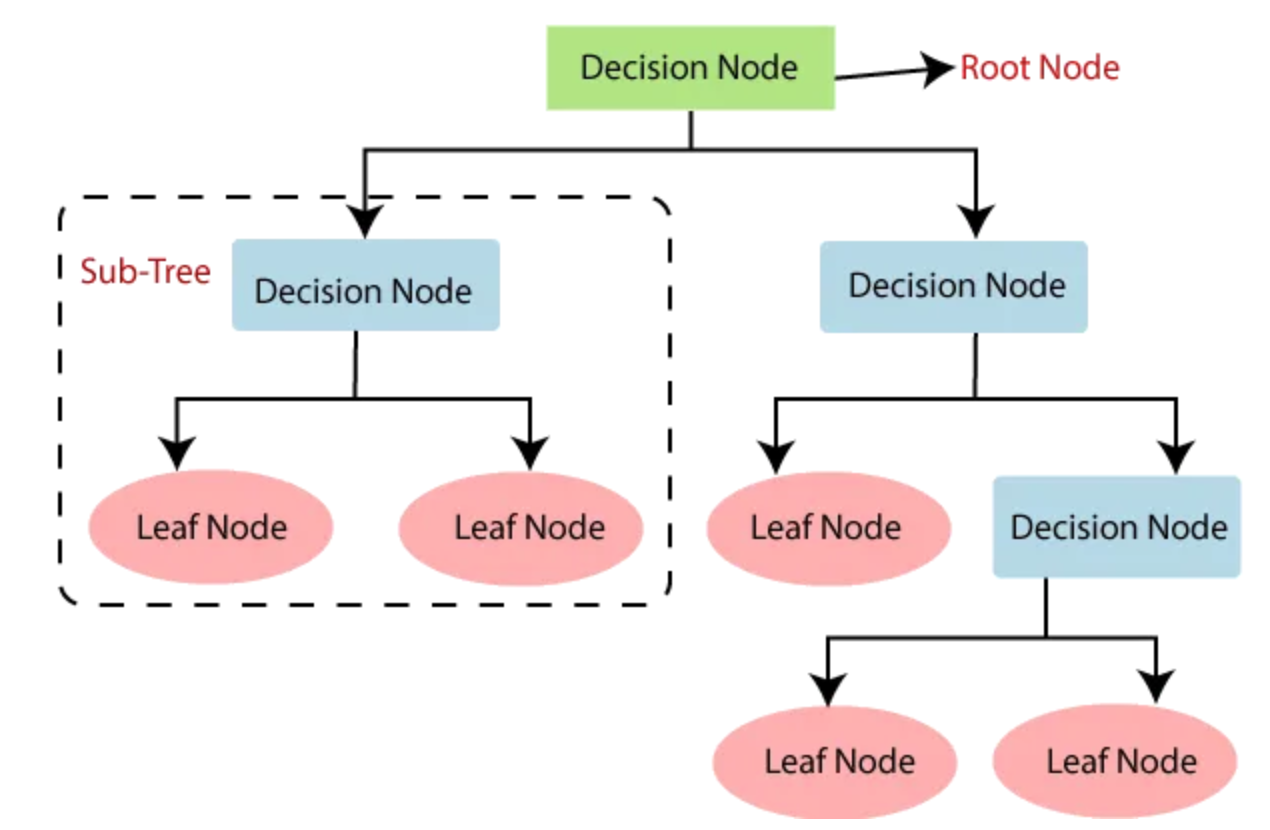

### Classification Tree Example

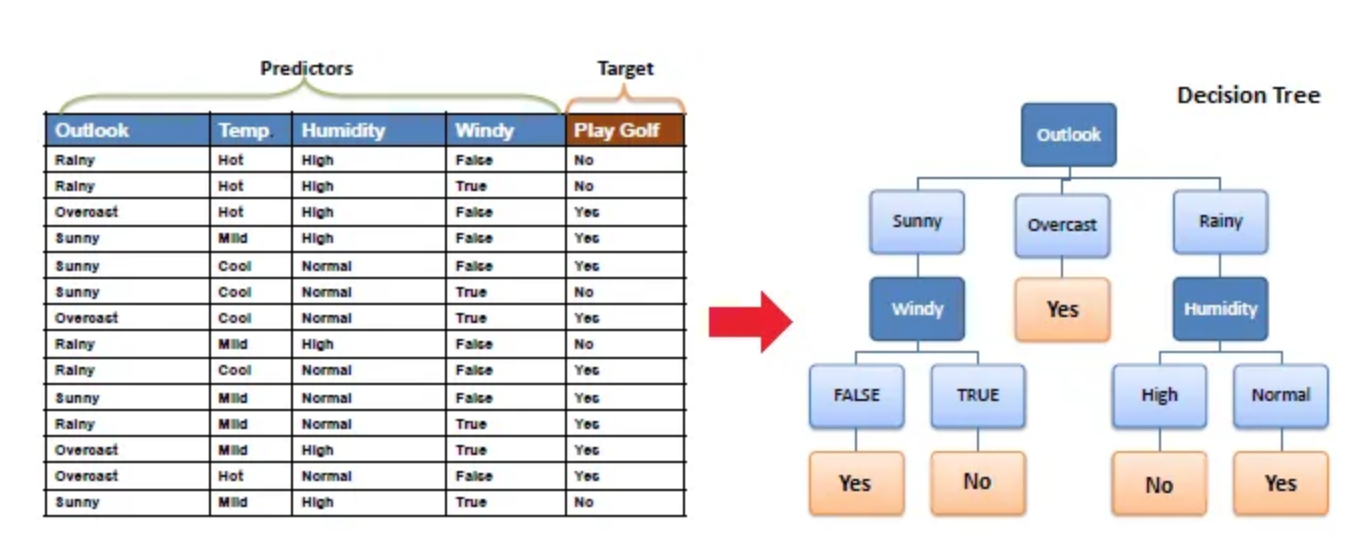



## Decision Trees at a glance:

*   A Decision Tree is a machine learning algorithm used for classification and regression, structured like an upside-down tree with nodes representing decisions and leaves representing outcomes.
*   The process involves splitting data based on features to create more homogeneous subsets.
*   Key components of a Decision Tree diagram include Root Nodes (initial decision), Internal Nodes (subsequent decisions), Leaf Nodes (final predictions), and Branches (outcomes of decisions).
*   Building a Decision Tree involves starting with a root node, iteratively choosing the best feature to split based on criteria like Gini impurity, Entropy, or Mean Squared Error, defining stopping conditions, and assigning predictions to leaf nodes. Pruning can be applied afterward to prevent overfitting.
*   We build a Decision Tree classifier using scikit-learn, including loading the dataset, splitting data into training and testing sets, training the model, making predictions, and evaluating accuracy.
*   Decision Trees are easy to understand, require little data preparation, handle both numerical and categorical data, and can model non-linear relationships.
*   However, they are prone to overfitting, sensitive to small data variations, can be biased with imbalanced datasets, and can have high computational complexity for large datasets.

## How does a decision tree algorithm work

### High-level Description:


**Root Node:**
The root node is the topmost node in a decision tree. It represents the initial decision point and the entire dataset before any splitting occurs. It's the starting point from which the tree branches out based on different features.
Its role is to initiate the decision-making process by considering the most significant feature for splitting the data.

**Internal Node (or Decision Node):**
An internal node is any node in the tree that is not a root node or a leaf node. It represents a decision point based on a specific feature, leading to further splitting of the data into subsets based on the feature's values. Each internal node has one incoming branch and two or more outgoing branches.
Its role is to continue the decision process by evaluating additional features and directing the data down different paths of the tree.

**Leaf Node (or Terminal Node):**
A leaf node is a node at the end of a branch that does not split further. It represents the final outcome, prediction, or class label. Once the decision-making process reaches a leaf node, a conclusion is made based on the path taken from the root.
Its role is to provide the final result of the decision tree for a given input.

**Splitting:**
Splitting is the process of dividing a node into two or more sub-nodes based on a splitting criterion (e.g., **Gini impurity**, **entropy**, or **mean squared error**) applied to a feature. The goal of splitting is to create subsets of data that are more homogeneous with respect to the target variable.
Its role is to partition the data effectively at each node, leading to a more accurate and interpretable tree structure.

**Pruning:**
Pruning is a technique used to reduce the size of a decision tree by removing nodes or branches that provide little predictive power. This is done to prevent overfitting, which is when the tree becomes too complex and learns the training data too well, performing poorly on unseen data.
Its role is to simplify the tree and improve its generalization ability on new data by removing unnecessary complexity.

## Step-by-step process:


Building a Decision Tree is an iterative process that starts with the entire dataset and recursively splits it based on features until a stopping condition is met.

**Step 1: Start with the Root Node**
The process begins with the root node, which contains the entire training dataset. This node represents the initial state before any decisions or splits are made. The goal is to find the best way to split this data to begin the tree structure.

**Step 2: Choose the Best Feature to Split**
At each node (starting with the root), the algorithm evaluates all available features to determine which one would best split the data. The 'best' split is the one that results in the most homogeneous subsets with respect to the target variable. This is where splitting criteria come into play.

**Step 3: Apply Splitting Criteria**
To evaluate the quality of a split, the algorithm uses splitting criteria. These criteria measure the impurity or homogeneity of the data subsets created by a potential split. Common criteria include:
  - **For Classification:**
    - **Gini Impurity:** Measures the probability of incorrectly classifying a randomly chosen element in the dataset if it were labeled randomly according to the distribution of labels in the subset.
    - **Entropy:** Measures the randomness or disorder of the data. A lower entropy indicates a more homogeneous subset.
  - **For Regression:**
    - **Mean Squared Error (MSE):** Measures the average squared difference between the actual and predicted values in the subset.
The algorithm calculates the impurity (or error) for different splits and chooses the split that minimizes impurity or error.

**Step 4: Iterative Splitting**
The process of choosing the best split and dividing the data is repeated recursively for each child node created in the previous step. This means the algorithm continues to build the tree downwards, creating new internal nodes and branches based on the best features to split the remaining data subsets.

**Step 5: Define Stopping Conditions**
The recursive splitting process doesn't continue indefinitely. The algorithm stops building the tree when one or more stopping conditions are met. These conditions prevent the tree from becoming too complex and overfitting the training data. Common stopping conditions include:
  - **Maximum Depth:** The tree stops splitting when it reaches a predefined maximum number of levels.
  - **Minimum Number of Samples per Leaf:** A node will not be split if the number of samples in it is below a certain threshold.
  - **Minimum Impurity Decrease:** A split is only performed if it results in a significant decrease in impurity (or error) above a certain threshold.
  - **No Further Improvement:** The splitting stops if no feature can produce a split that improves the impurity or error measure.

**Step 6: Assign Predictions to Leaf Nodes**
Once the tree building process stops, the terminal nodes are designated as leaf nodes. Each leaf node represents a final prediction. The prediction assigned to a leaf node is typically determined by the majority class of the samples that fall into that leaf (for classification) or the average value of the target variable for those samples (for regression).

**Step 7: Consider Pruning (Post-Building)**
After the initial tree is built, a technique called pruning is often applied. Pruning involves removing branches or nodes that contribute little to the predictive accuracy on unseen data. This helps to simplify the tree and improve its generalization ability, preventing overfitting. (More details on pruning will be discussed later).

### Gini Impurity (Giny Index)
For a dataset with $c$ classes, it is calculated as:

$Gini(S) = 1 - \sum_{i=1}^{c} p_i^2$

where:
- $Gini(S)$ is the Gini index of the dataset $S$.
- $c$ is the number of classes.
- $p_i$ is the proportion of instances in the dataset that belong to class $i$.


### Entropy
For a dataset with $c$ classes, the entropy is calculated as:

$H(S) = -\sum_{i=1}^{c} p_i \log_2(p_i)$

where:
- $H(S)$ is the entropy of the dataset $S$.
- $c$ is the number of classes.
- $p_i$ is the proportion of instances in the dataset that belong to class $i$.

**Information Gain** is a measure used in the construction of decision trees to decide which attribute at each step best splits the data. It quantifies the reduction in entropy or impurity achieved by splitting the data based on a particular attribute.

The formula for Information Gain when splitting a dataset $S$ on an attribute $A$ is:

$IG(S, A) = H(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} H(S_v)$

Where:
- $H(S)$ is the entropy of the dataset $S$ before the split.
- $Values(A)$ are the possible values of attribute $A$.
- $S_v$ is the subset of dataset $S$ for which attribute $A$ has value $v$.
- $|S_v|$ is the number of instances in $S_v$.
- $|S|$ is the total number of instances in $S$.
- $H(S_v)$ is the entropy of the subset $S_v$.

Essentially, Information Gain is the entropy of the parent node minus the weighted average of the entropy of the child nodes. A higher information gain indicates a better split.

In [ ]:
import numpy as np

def entropy(m, n):
  """Calculates the binary entropy given counts m and n.

  Args:
    m: The count of the first outcome.
    n: The count of the second outcome.

  Returns:
    The binary entropy.
  """
  total = m + n
  if total == 0:
    return 0
  p_m = m / total
  p_n = n / total

  # Handle the case where p_m or p_n is 0 to avoid log(0)
  entropy_value = 0
  if p_m > 0:
    entropy_value -= p_m * np.log2(p_m)
  if p_n > 0:
    entropy_value -= p_n * np.log2(p_n)

  return entropy_value

# Example usage:
print(f"Entropy for m=9, n=5: {entropy(9, 5)}")
print(f"Entropy for m=3, n=2: {entropy(3, 2)}")
print(f"Entropy for m=3, n=4: {entropy(3, 4)}")
print(f"Entropy for m=3, n=3: {entropy(3, 3)}")
print(f"Entropy for m=4, n=2: {entropy(4, 2)}")
print(f"Entropy for m=2, n=2: {entropy(2, 2)}")
print(f"Entropy for m=4, n=0: {entropy(4, 0)}")
print(f"Entropy for m=3, n=1: {entropy(3, 1)}")
print(f"Entropy for m=6, n=1: {entropy(6, 1)}")
print(f"Entropy for m=6, n=2: {entropy(6, 2)}")

Entropy for m=9, n=5: 0.9402859586706311
Entropy for m=3, n=2: 0.9709505944546686
Entropy for m=3, n=4: 0.9852281360342515
Entropy for m=3, n=3: 1.0
Entropy for m=4, n=2: 0.9182958340544896
Entropy for m=2, n=2: 1.0
Entropy for m=4, n=0: 0.0
Entropy for m=3, n=1: 0.8112781244591328
Entropy for m=6, n=1: 0.5916727785823275
Entropy for m=6, n=2: 0.8112781244591328


In [ ]:
# Let's consider our example to calculate information gain.
# We have a dataset with 14 instances and a binary target variable (e.g., Yes/No).
# Before splitting, we have 9 'Yes' and 5 'No'.

# Calculate the entropy of the parent node (before the split)
entropy_parent = entropy(9, 5)
print(f"Entropy of the parent node: {entropy_parent:.4f}")

# Now, let's consider splitting on an attribute, say 'Outlook', with values 'Sunny', 'Overcast', and 'Rainy'.
# Suppose after splitting on 'Outlook', we have the following counts for 'Yes'/'No':
# Sunny: 2 'Yes', 3 'No'
# Overcast: 4 'Yes', 0 'No'
# Rainy: 3 'Yes', 2 'No'

# Calculate the entropy for each child node
entropy_sunny = entropy(2, 3)
entropy_overcast = entropy(4, 0)
entropy_rainy = entropy(3, 2)

print(f"Entropy for Sunny: {entropy_sunny:.4f}")
print(f"Entropy for Overcast: {entropy_overcast:.4f}")
print(f"Entropy for Rainy: {entropy_rainy:.4f}")

# Calculate the weighted average entropy of the child nodes
# Total instances = 2+3 + 4+0 + 3+2 = 14
weighted_entropy_children = (5/14) * entropy_sunny + (4/14) * entropy_overcast + (5/14) * entropy_rainy
print(f"Weighted entropy of child nodes: {weighted_entropy_children:.4f}")

# Calculate Information Gain
information_gain = entropy_parent - weighted_entropy_children
print(f"Information Gain: {information_gain:.4f}")

Entropy of the parent node: 0.9403
Entropy for Sunny: 0.9710
Entropy for Overcast: 0.0000
Entropy for Rainy: 0.9710
Weighted entropy of child nodes: 0.6935
Information Gain: 0.2467


#### Calculate (Whiteboard)

## Decision Tree to Decision Rule

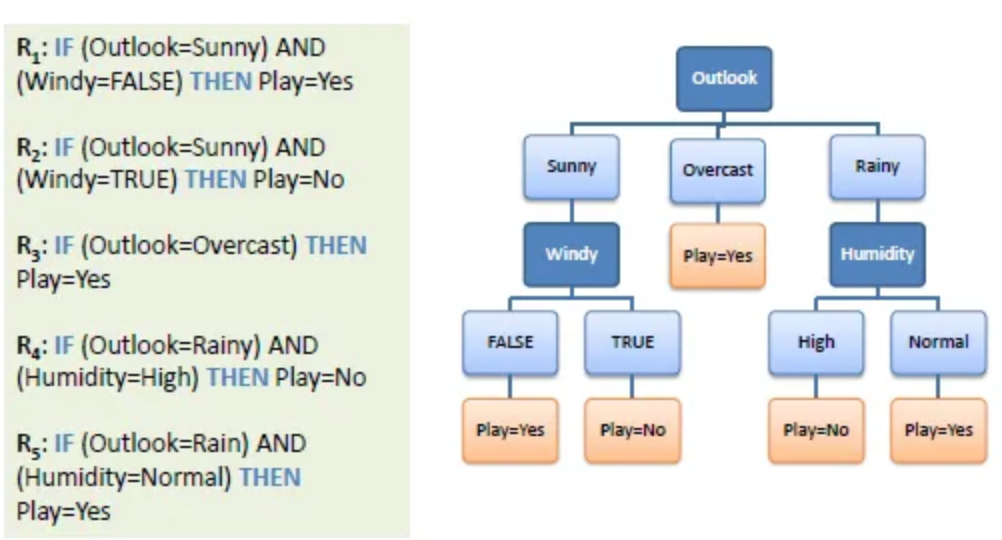

In [ ]:
## Function to calculate Gini Index

def gini_index(counts):
  """Calculates the Gini index for a list of counts.

  Args:
    counts: A list or array of counts for each class.

  Returns:
    The Gini index.
  """
  total = sum(counts)
  if total == 0:
    return 0

  gini = 1.0
  for count in counts:
    probability = count / total
    gini -= probability**2
  return gini

# Example usage:
print(f"Gini index for counts [9, 5]: {gini_index([9, 5])}")
print(f"Gini index for counts [3, 2]: {gini_index([3, 2])}")
print(f"Gini index for counts [3, 4]: {gini_index([3, 4])}")
print(f"Gini index for counts [3, 3]: {gini_index([3, 3])}")
print(f"Gini index for counts [4, 2]: {gini_index([4, 2])}")
print(f"Gini index for counts [4, 0]: {gini_index([4, 0])}")
print(f"Gini index for counts [3, 1]: {gini_index([3, 1])}")
print(f"Gini index for counts [6, 1]: {gini_index([6, 1])}")
print(f"Gini index for counts [6, 2]: {gini_index([6, 2])}")

Gini index for counts [9, 5]: 0.4591836734693877
Gini index for counts [3, 2]: 0.48
Gini index for counts [3, 4]: 0.489795918367347
Gini index for counts [3, 3]: 0.5
Gini index for counts [4, 2]: 0.4444444444444445
Gini index for counts [4, 0]: 0.0
Gini index for counts [3, 1]: 0.375
Gini index for counts [6, 1]: 0.24489795918367355
Gini index for counts [6, 2]: 0.375


In [ ]:
!pip install dtreeviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 9.6 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Example code using scikit-learn




We build and use a Decision Tree in Python using scikit-learn. This involves importing necessary libraries, loading a dataset, splitting it, creating and training the model, making predictions, and evaluating performance. All these steps can be combined into a single code block.



In [ ]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import *
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


import dtreeviz
import graphviz.backend as be
from IPython.display import Image, display_svg, SVG
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

import numpy as np
%matplotlib inline

In [ ]:
# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Decision Tree classifier object
dt_classifier = DecisionTreeClassifier()

# Train the Decision Tree classifier on the training data
dt_classifier.fit(X_train, y_train)

# Make predictions on the testing data
y_pred = dt_classifier.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy score
print(f"Accuracy of the Decision Tree Classifier: {accuracy}")

Accuracy of the Decision Tree Classifier: 1.0


In [ ]:
observation = [[ 5, 4, 3, 2]] # Predict observation's class
dt_classifier.predict(observation)
dt_classifier.predict_proba(observation)

array([[0., 0., 1.]])

[Text(0.3076923076923077, 0.9285714285714286, 'x[3] <= 0.8\ngini = 0.667\nsamples = 120\nvalue = [40, 41, 39]'),
 Text(0.23076923076923078, 0.7857142857142857, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]'),
 Text(0.2692307692307693, 0.8571428571428572, 'True  '),
 Text(0.38461538461538464, 0.7857142857142857, 'x[2] <= 4.75\ngini = 0.5\nsamples = 80\nvalue = [0, 41, 39]'),
 Text(0.34615384615384615, 0.8571428571428572, '  False'),
 Text(0.15384615384615385, 0.6428571428571429, 'x[3] <= 1.65\ngini = 0.053\nsamples = 37\nvalue = [0, 36, 1]'),
 Text(0.07692307692307693, 0.5, 'gini = 0.0\nsamples = 36\nvalue = [0, 36, 0]'),
 Text(0.23076923076923078, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.6153846153846154, 0.6428571428571429, 'x[3] <= 1.75\ngini = 0.206\nsamples = 43\nvalue = [0, 5, 38]'),
 Text(0.38461538461538464, 0.5, 'x[2] <= 4.95\ngini = 0.5\nsamples = 8\nvalue = [0, 4, 4]'),
 Text(0.3076923076923077, 0.35714285714285715, 'gini = 0.0\nsamples = 2\nvalue = [0, 2, 

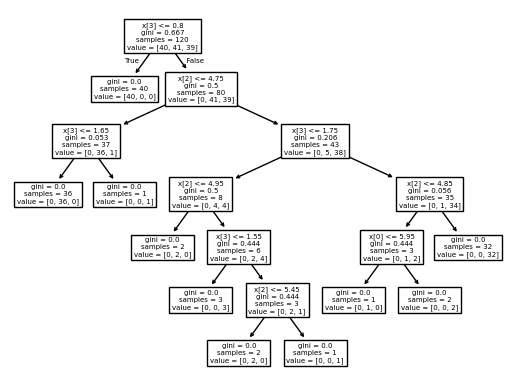

In [ ]:
plot_tree(dt_classifier)

In [ ]:
viz = dtreeviz.model(dt_classifier, X_train, y_train, feature_names=iris.feature_names,
               class_names=["setosa", "versicolor", "virginica"])
viz

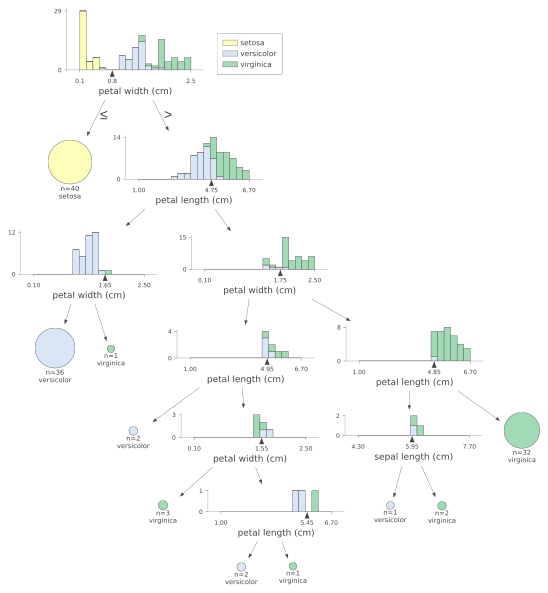

In [ ]:
viz.view(scale=1)

## Advantages and disadvantages

### Advantages of Decision Trees

*   **Easy to Understand and Interpret:** Decision trees mimic human thinking and decision-making processes, making them highly intuitive and easy to explain to non-experts.
*   **Require Little Data Preparation:** Unlike some algorithms, decision trees do not require feature scaling or normalization.
*   **Handle Both Numerical and Categorical Data:** Decision trees can work with both types of data without extensive preprocessing.
*   **Can Model Non-linear Relationships:** Decision trees can capture complex non-linear relationships between features and the target variable.

### Disadvantages of Decision Trees

*   **Prone to Overfitting:** Without proper pruning or setting of stopping conditions, decision trees can become too complex and overfit the training data, performing poorly on unseen data.
*   **Sensitive to Small Variations in Data:** A small change in the data can sometimes lead to a completely different tree structure.
*   **Can Create Biased Trees with Imbalanced Datasets:** If the dataset has a dominant class, the tree might be biased towards that class.
*   **Computational Complexity for Large Datasets:** Building a deep decision tree on a very large dataset can be computationally expensive.

## Common Decision Tree Algorithms:
* ### ID3 (Iterative Dichotomiser 3)
* ### Classification and Regression Tree (CART)

### ID3 Algorithm

The ID3 algorithm is a decision tree learning algorithm that is used for classification tasks. It builds a decision tree by recursively partitioning the dataset based on the attribute that provides the most information gain.

Here are the key steps of the ID3 algorithm:

1.  **Calculate the Entropy of the Target Variable:** Start by calculating the entropy of the target variable for the entire dataset. This measures the impurity or randomness in the target variable before any splitting.

2.  **For each attribute:**
    *   Calculate the entropy for each possible value of the attribute.
    *   Calculate the weighted average entropy of the child nodes after splitting on that attribute.
    *   Calculate the **Information Gain** for the attribute. Information Gain is the reduction in entropy achieved by splitting on the attribute.

3.  **Select the Best Attribute:** Choose the attribute with the highest Information Gain as the splitting criterion for the current node. This attribute is considered the most informative for partitioning the data.

4.  **Create a Node:** Create a decision node based on the selected attribute.

5.  **Split the Dataset:** Split the dataset into subsets based on the values of the chosen attribute. Each subset corresponds to a branch of the decision tree.

6.  **Recursively Build the Tree:** Repeat the process (steps 1-5) for each subset until one of the following stopping conditions is met:
    *   All instances in a subset belong to the same class. This forms a leaf node labeled with that class.
    *   There are no remaining attributes to split on.
    *   There are no instances in the subset.

**Key Concepts:**

*   **Entropy:** A measure of impurity or randomness in a set of data. Higher entropy means more impurity.
*   **Information Gain:** The reduction in entropy achieved by splitting the data on an attribute. The attribute with the highest information gain is chosen for splitting.

**Limitations of ID3:**

*   ID3 is designed for categorical attributes and can have difficulty handling continuous attributes.
*   It is prone to overfitting, especially with noisy data or when there are many attributes.
*   It does not handle missing values.

Later algorithms like C4.5 and C5.0 were developed to address some of these limitations.

### CART Algorithm

CART (Classification and Regression Trees) is a decision tree algorithm that can be used for both classification and regression tasks. It builds a binary decision tree by recursively splitting the data based on a single attribute and a single split point at each node.

Here are the key aspects of the CART algorithm:

1.  **Binary Splits:** Unlike ID3 which can create multi-way splits for categorical features, CART always creates binary splits. Each node in a CART tree will have exactly two branches.

2.  **Splitting Criteria:**
    *   For **classification**, CART typically uses the **Gini impurity** (or sometimes entropy) to evaluate the quality of a split. The algorithm chooses the split that minimizes the weighted impurity of the child nodes.
    *   For **regression**, CART uses metrics like **Mean Squared Error (MSE)** or **Mean Absolute Error (MAE)** to evaluate splits. It aims to minimize the error within each child node.

3.  **Finding the Best Split:** For each attribute, CART considers all possible split points. For numerical attributes, it considers splitting at the midpoint between sorted unique values. For categorical attributes, it may group categories to create binary splits. The algorithm selects the attribute and split point that result in the best improvement in the splitting criterion (e.g., maximum reduction in Gini impurity for classification).

4.  **Stopping Conditions:** The recursive splitting process stops when one of the following conditions is met:
    *   The node is pure (all instances in the node belong to the same class for classification, or the variance is below a threshold for regression).
    *   The number of instances in the node is below a predefined minimum.
    *   The tree reaches a predefined maximum depth.
    *   No split improves the splitting criterion by a sufficient amount.

5.  **Pruning (Optional but Recommended):** CART often grows a large tree and then prunes it back to avoid overfitting. Pruning involves removing branches that do not contribute significantly to the tree's predictive accuracy on a validation set.

**Key Differences from ID3:**

*   CART produces strictly binary trees, while ID3 can produce multi-way trees.
*   CART can handle both classification and regression tasks, while ID3 is primarily for classification.
*   CART commonly uses Gini impurity, while ID3 uses Information Gain (based on entropy).
*   CART has built-in mechanisms for handling continuous attributes and pruning.

CART is a widely used and versatile decision tree algorithm.

# A Decision Tree Model Example
We tune a Decision Tree model on the customer dataset using hyperparameter tuning and evaluate its performance.

In [ ]:
import pandas as pd
customer_df = pd.read_csv('drive/My Drive/Colab Notebooks/customer_data.csv')
customer_df.head(10)

,id,age,gender,income,education,region,loyalty_status,purchase_frequency,purchase_amount,product_category,promotion_usage,satisfaction_score
0,1,27,Male,40682,Bachelor,East,Gold,frequent,18249,Books,0,6
1,2,29,Male,15317,Masters,West,Regular,rare,4557,Clothing,1,6
2,3,37,Male,38849,Bachelor,West,Silver,rare,11822,Clothing,0,6
3,4,30,Male,11568,HighSchool,South,Regular,frequent,4098,Food,0,7
4,5,31,Female,46952,College,North,Regular,occasional,19685,Clothing,1,5
5,6,38,Male,7347,Bachelor,South,Silver,occasional,2822,Electronics,0,5
6,7,32,Female,8265,Bachelor,South,Silver,frequent,3293,Clothing,0,7
7,8,24,Female,47773,HighSchool,North,Regular,rare,21794,Books,0,5
8,9,27,Male,19154,College,East,Regular,occasional,5819,Clothing,0,5
9,10,28,Female,24666,HighSchool,North,Regular,rare,8779,Food,0,6


In [ ]:
# Load and prepare data

# 1. Drop the 'id' column
customer_df = customer_df.drop('id', axis=1)

# 2. Identify the categorical columns
categorical_cols = customer_df.select_dtypes(include='object').columns.tolist()

# 3. Apply one-hot encoding to categorical columns
customer_df_encoded = pd.get_dummies(customer_df, columns=categorical_cols, drop_first=True)

# 4. Separate features (X) and target variable (y)
X = customer_df_encoded.drop('loyalty_status_Regular', axis=1) # Assuming 'Regular' is the baseline/dropped category after encoding
y = customer_df_encoded['loyalty_status_Regular'] # Target is the encoded 'loyalty_status'

# 5. Split the data into training and testing sets
X_train_customer, X_test_customer, y_train_customer, y_test_customer = train_test_split(X, y, test_size=0.2, random_state=42)

display(X_train_customer.head())
display(y_train_customer.head())

,age,income,purchase_amount,promotion_usage,satisfaction_score,gender_Male,education_College,education_HighSchool,education_Masters,region_North,...,region_West,loyalty_status_Silver,purchase_frequency_occasional,purchase_frequency_rare,product_category_Books,product_category_Clothing,product_category_Electronics,product_category_Food,product_category_Health,product_category_Home
75220,24,29205,9284,0,5,True,False,False,True,False,...,True,False,False,True,False,True,False,False,False,False
48955,38,47963,18303,0,5,True,True,False,False,False,...,True,False,False,True,False,False,False,True,False,False
44966,33,24892,10136,0,5,True,False,True,False,False,...,False,False,False,True,False,False,False,False,False,False
13568,27,35385,12654,0,5,False,True,False,False,False,...,False,False,False,True,False,False,True,False,False,False
92727,28,46088,18674,0,5,False,False,True,False,False,...,False,False,False,True,False,True,False,False,False,False


,loyalty_status_Regular
75220,True
48955,True
44966,False
13568,True
92727,True


In [ ]:
# Decision Tree Model

dt_model = DecisionTreeClassifier(random_state=42)

In [ ]:
# Hyper parameter tuning

# Define hyper parameter grid (how many elements?)

param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

In [ ]:
# Perform Grid Search

from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(dt_model, param_grid, cv=5)
grid_search.fit(X_train_customer, y_train_customer)
print("Best hyperparameters found:")
print(grid_search.best_params_)

Best hyperparameters found:
{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [ ]:
# Train the model

best_dt_model = grid_search.best_estimator_
best_dt_model.fit(X_train_customer, y_train_customer)
print("Best model trained on the entire training dataset.")

Best model trained on the entire training dataset.


In [ ]:
# Evaluate the model

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Make predictions on the test set
y_pred_customer = best_dt_model.predict(X_test_customer)

# Calculate and print accuracy
accuracy_customer = accuracy_score(y_test_customer, y_pred_customer)
print(f"Accuracy of the tuned Decision Tree model: {accuracy_customer:.4f}")

# Calculate and print other classification metrics
precision_customer = precision_score(y_test_customer, y_pred_customer)
recall_customer = recall_score(y_test_customer, y_pred_customer)
f1_customer = f1_score(y_test_customer, y_pred_customer)

print(f"Precision: {precision_customer:.4f}")
print(f"Recall: {recall_customer:.4f}")
print(f"F1-score: {f1_customer:.4f}")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test_customer, y_pred_customer))

Accuracy of the tuned Decision Tree model: 0.9040
Precision: 0.8622
Recall: 1.0000
F1-score: 0.9260

Classification Report:
              precision    recall  f1-score   support

       False       1.00      0.76      0.86      7983
        True       0.86      1.00      0.93     12017

    accuracy                           0.90     20000
   macro avg       0.93      0.88      0.89     20000
weighted avg       0.92      0.90      0.90     20000



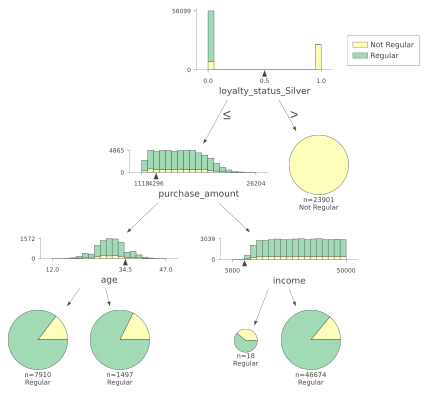

In [ ]:
# Visualizing the Tree

# Get feature names from the encoded training data
customer_feature_names = X_train_customer.columns.tolist()

# Since we are predicting 'loyalty_status_Regular' (True/False), the classes for the visualization
# should correspond to the original categories that map to True and False.
# If 'loyalty_status_Regular' is True, the original status was 'Regular'.
# If 'loyalty_status_Regular' is False, the original status was NOT 'Regular' (i.e., 'Gold' or 'Silver').
# So, the class names for the visualization should be ['Not Regular', 'Regular'].
customer_class_names = ['Not Regular', 'Regular']


viz_customer = dtreeviz.model(best_dt_model, X_train_customer, y_train_customer,
                         feature_names=customer_feature_names,
                         class_names=customer_class_names)

viz_customer.view(scale=1)

## Summary:

### Data Analysis Key Findings

*   The best hyperparameters found for the Decision Tree model using GridSearchCV were `{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}`.
*   The tuned Decision Tree model achieved an accuracy of 0.9040 on the test dataset.
*   The model exhibited a perfect recall (1.0000) for the positive class, correctly identifying all actual positive instances.
*   The precision for the positive class was 0.8622.
*   The F1-score for the positive class was 0.9260.

### Next Steps

*   The tuned Decision Tree model performs well, especially in identifying positive cases, as indicated by the high recall and F1-score.
*   We now check the feature importance from the best model to understand which features are most influential in determining the target variable.

In [ ]:
# Get feature importances from the trained model
feature_importances = best_dt_model.feature_importances_

# Get the names of the features
feature_names = X_train_customer.columns

# Create a pandas Series to associate feature names with their importances
feature_importance_series = pd.Series(feature_importances, index=feature_names)

# Sort the feature importances in descending order
sorted_feature_importances = feature_importance_series.sort_values(ascending=False)

# Print the sorted feature importances
print("Feature Importances:")
display(sorted_feature_importances)

Feature Importances:


,0
loyalty_status_Silver,0.999738
age,0.000095
income,0.000090
purchase_amount,0.000077
promotion_usage,0.000000
satisfaction_score,0.000000
gender_Male,0.000000
education_HighSchool,0.000000
education_College,0.000000
education_Masters,0.000000


## Regression Trees

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler

# Create dataset
dataset_dict = {
    'Outlook': ['sunny', 'sunny', 'overcast', 'rain', 'rain', 'rain', 'overcast', 'sunny', 'sunny', 'rain', 'sunny', 'overcast', 'overcast', 'rain', 'sunny', 'overcast', 'rain', 'sunny', 'sunny', 'rain', 'overcast', 'rain', 'sunny', 'overcast', 'sunny', 'overcast', 'rain', 'overcast'],
    'Temperature': [85.0, 80.0, 83.0, 70.0, 68.0, 65.0, 64.0, 72.0, 69.0, 75.0, 75.0, 72.0, 81.0, 71.0, 81.0, 74.0, 76.0, 78.0, 82.0, 67.0, 85.0, 73.0, 88.0, 77.0, 79.0, 80.0, 66.0, 84.0],
    'Humidity': [85.0, 90.0, 78.0, 96.0, 80.0, 70.0, 65.0, 95.0, 70.0, 80.0, 70.0, 90.0, 75.0, 80.0, 88.0, 92.0, 85.0, 75.0, 92.0, 90.0, 85.0, 88.0, 65.0, 70.0, 60.0, 95.0, 70.0, 78.0],
    'Wind': [False, True, False, False, False, True, True, False, False, False, True, True, False, True, True, False, False, True, False, True, True, False, True, False, False, True, False, False],
    'Num_Players': [52,39,43,37,28,19,43,47,56,33,49,23,42,13,33,29,25,51,41,14,34,29,49,36,57,21,23,41]
}

df = pd.DataFrame(dataset_dict)

In [ ]:
df.head()

,Outlook,Temperature,Humidity,Wind,Num_Players
0,sunny,85.0,85.0,False,52
1,sunny,80.0,90.0,True,39
2,overcast,83.0,78.0,False,43
3,rain,70.0,96.0,False,37
4,rain,68.0,80.0,False,28


In [ ]:
# One-hot encode 'Outlook' column
df = pd.get_dummies(df, columns=['Outlook'], prefix='', prefix_sep='', dtype=int)

# Convert 'Wind' column to binary
df['Wind'] = df['Wind'].astype(int)

# Split data into features and target, then into training and test sets
X, y = df.drop(columns='Num_Players'), df['Num_Players']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5, shuffle=False)

# Scale the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize Decision Tree Regressor
tree = DecisionTreeRegressor(random_state=42)

In [ ]:
regr = DecisionTreeRegressor(random_state=42)
regr.fit(X_train_scaled, y_train)

# Make predictions
y_pred = regr.predict(X_test_scaled)

# Calculate and print RMSE

rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse:.4f}")

RMSE: 5.2712


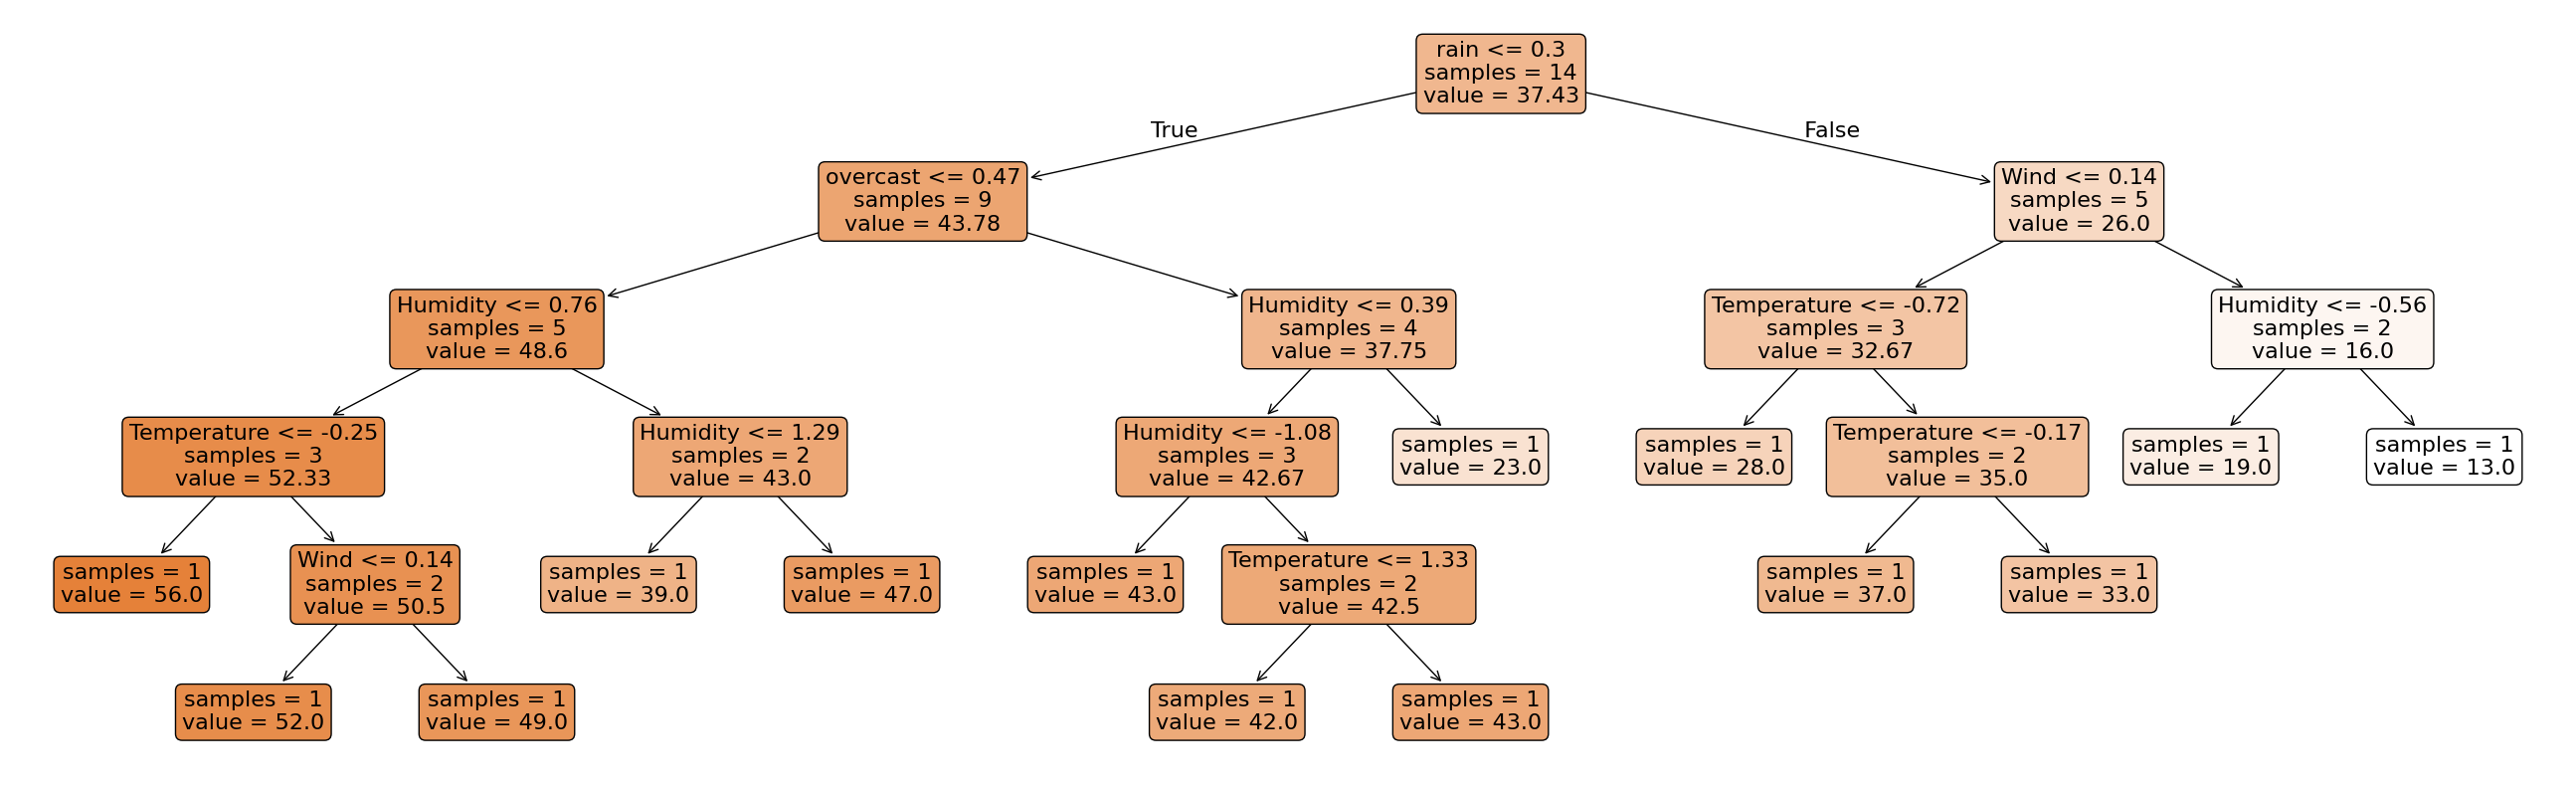

In [ ]:
# Visualize the decision tree
plt.figure(figsize=(26,8))
plot_tree(regr, feature_names=X.columns, filled=True, rounded=True, impurity=False, fontsize=16, precision=2)
plt.tight_layout()
plt.show()

# Lecture 2
* ## Review
  * Decision Tree Classifier &mdash; Student Presentation
  * Decision Tree Regressor
* ## Ensemble Methods

## Decision Tree Classiffier

## Decision Tree Regressor
  * Step 1: Begin with the training data
  * Step 2: For each feature
    * Sort feature values in ascending order
    * Consider all mid-points between adjacent values as potential split points.
  * Step 3: For each potential split point
    * Calculate MSE of current node
    * Compute weighted average of errors for the resulting split.
  * Step 4: After evaluating all features and split points, select the one with the minimum MSE.
  * Step 5: Create two child nodes based on the chosen feature and split point &mdash;
    * Left child: samples with feature value <= split point
    * Right child: samples with feature value > split point
  * Step 6: Recursively repeat steps 2&mdash;5 for each child node. Continue until a stopping criterion is met.
  * Step 7: At each leaf node, assign the average target values of the samples in that node as the prediction.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler

# Create dataset
dataset_dict = {
    'Outlook': ['sunny', 'sunny', 'overcast', 'rain', 'rain', 'rain', 'overcast', 'sunny', 'sunny', 'rain', 'sunny', 'overcast', 'overcast', 'rain', 'sunny', 'overcast', 'rain', 'sunny', 'sunny', 'rain', 'overcast', 'rain', 'sunny', 'overcast', 'sunny', 'overcast', 'rain', 'overcast'],
    'Temperature': [85.0, 80.0, 83.0, 70.0, 68.0, 65.0, 64.0, 72.0, 69.0, 75.0, 75.0, 72.0, 81.0, 71.0, 81.0, 74.0, 76.0, 78.0, 82.0, 67.0, 85.0, 73.0, 88.0, 77.0, 79.0, 80.0, 66.0, 84.0],
    'Humidity': [85.0, 90.0, 78.0, 96.0, 80.0, 70.0, 65.0, 95.0, 70.0, 80.0, 70.0, 90.0, 75.0, 80.0, 88.0, 92.0, 85.0, 75.0, 92.0, 90.0, 85.0, 88.0, 65.0, 70.0, 60.0, 95.0, 70.0, 78.0],
    'Wind': [False, True, False, False, False, True, True, False, False, False, True, True, False, True, True, False, False, True, False, True, True, False, True, False, False, True, False, False],
    'Num_Players': [52,39,43,37,28,19,43,47,56,33,49,23,42,13,33,29,25,51,41,14,34,29,49,36,57,21,23,41]
}

df = pd.DataFrame(dataset_dict)

In [ ]:
df.head()

,Outlook,Temperature,Humidity,Wind,Num_Players
0,sunny,85.0,85.0,False,52
1,sunny,80.0,90.0,True,39
2,overcast,83.0,78.0,False,43
3,rain,70.0,96.0,False,37
4,rain,68.0,80.0,False,28


In [ ]:
# One-hot encode 'Outlook' column
df = pd.get_dummies(df, columns=['Outlook'],prefix='',prefix_sep='')

# Convert 'Wind' column to binary
df['Wind'] = df['Wind'].astype(int)

# Rearrange columns
column_order = ['sunny', 'overcast', 'rain', 'Temperature', 'Humidity', 'Wind', 'Num_Players']
df = df[column_order]

# Split features and target
X, y = df.drop('Num_Players', axis=1), df['Num_Players']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5, shuffle=False)

### Over to spreadsheet

In [ ]:
def calculate_split_mse(X_train, y_train, feature_name, split_point):
    # Create DataFrame and sort by feature
    analysis_df = pd.DataFrame({
        'feature': X_train[feature_name],
        'y_actual': y_train
    }).sort_values('feature')

    # Split data and calculate means
    left_mask = analysis_df['feature'] <= split_point
    left_mean = analysis_df[left_mask]['y_actual'].mean()
    right_mean = analysis_df[~left_mask]['y_actual'].mean()

    # Calculate squared differences
    analysis_df['squared_diff'] = np.where(
        left_mask,
        (analysis_df['y_actual'] - left_mean) ** 2,
        (analysis_df['y_actual'] - right_mean) ** 2
    )

    # Calculate MSEs and counts
    left_mse = analysis_df[left_mask]['squared_diff'].mean()
    right_mse = analysis_df[~left_mask]['squared_diff'].mean()
    n_left = sum(left_mask)
    n_right = len(analysis_df) - n_left

    # Calculate weighted average MSE
    weighted_mse = (n_left * left_mse + n_right * right_mse) / len(analysis_df)

    # Print results
    print(analysis_df)
    print(f"nResults for split at {split_point} on feature '{feature_name}':")
    print(f"Left child MSE (n={n_left}, mean={left_mean:.2f}): {left_mse:.2f}")
    print(f"Right child MSE (n={n_right}, mean={right_mean:.2f}): {right_mse:.2f}")
    print(f"Weighted average MSE: {weighted_mse:.2f}")

# Example usage:
calculate_split_mse(X_train, y_train, 'Temperature', 73.5)

    feature  y_actual  squared_diff
6      64.0        43       95.0625
5      65.0        19      203.0625
4      68.0        28       27.5625
8      69.0        56      517.5625
3      70.0        37       14.0625
13     71.0        13      410.0625
7      72.0        47      189.0625
11     72.0        23      105.0625
10     75.0        49       36.0000
9      75.0        33      100.0000
1      80.0        39       16.0000
12     81.0        42        1.0000
2      83.0        43        0.0000
0      85.0        52       81.0000
nResults for split at 73.5 on feature 'Temperature':
Left child MSE (n=8, mean=33.25): 195.19
Right child MSE (n=6, mean=43.00): 39.00
Weighted average MSE: 128.25


In [ ]:
def evaluate_all_splits(X_train, y_train):
    """Evaluate all possible split points using midpoints for all features"""
    results = []

    for feature in X_train.columns:
        data = pd.DataFrame({'feature': X_train[feature], 'y_actual': y_train})
        splits = [(a + b)/2 for a, b in zip(sorted(data['feature'].unique())[:-1],
                                          sorted(data['feature'].unique())[1:])]

        for split in splits:
            left_mask = data['feature'] <= split
            n_left = sum(left_mask)

            if not (0 < n_left < len(data)): continue

            left_mean = data[left_mask]['y_actual'].mean()
            right_mean = data[~left_mask]['y_actual'].mean()

            left_mse = ((data[left_mask]['y_actual'] - left_mean) ** 2).mean()
            right_mse = ((data[~left_mask]['y_actual'] - right_mean) ** 2).mean()

            weighted_mse = (n_left * left_mse + (len(data) - n_left) * right_mse) / len(data)

            results.append({'Feature': feature, 'Split_Point': split, 'Weighted_MSE': weighted_mse})

    return pd.DataFrame(results).round(2)

# Example usage:
results = evaluate_all_splits(X_train, y_train)
print(results)

        Feature  Split_Point  Weighted_MSE
0         sunny          0.5         82.20
1      overcast          0.5        151.49
2          rain          0.5         78.97
3   Temperature         64.5        149.14
4   Temperature         66.5        144.64
5   Temperature         68.5        136.48
6   Temperature         69.5        151.19
7   Temperature         70.5        151.15
8   Temperature         71.5        134.52
9   Temperature         73.5        128.25
10  Temperature         77.5        134.26
11  Temperature         80.5        133.02
12  Temperature         82.0        134.62
13  Temperature         84.0        135.20
14     Humidity         67.5        149.14
15     Humidity         72.5        144.06
16     Humidity         76.5        140.91
17     Humidity         79.0        135.86
18     Humidity         82.5        148.91
19     Humidity         87.5        151.19
20     Humidity         92.5        148.05
21     Humidity         95.5        151.52
22         

RMSE: 5.5291


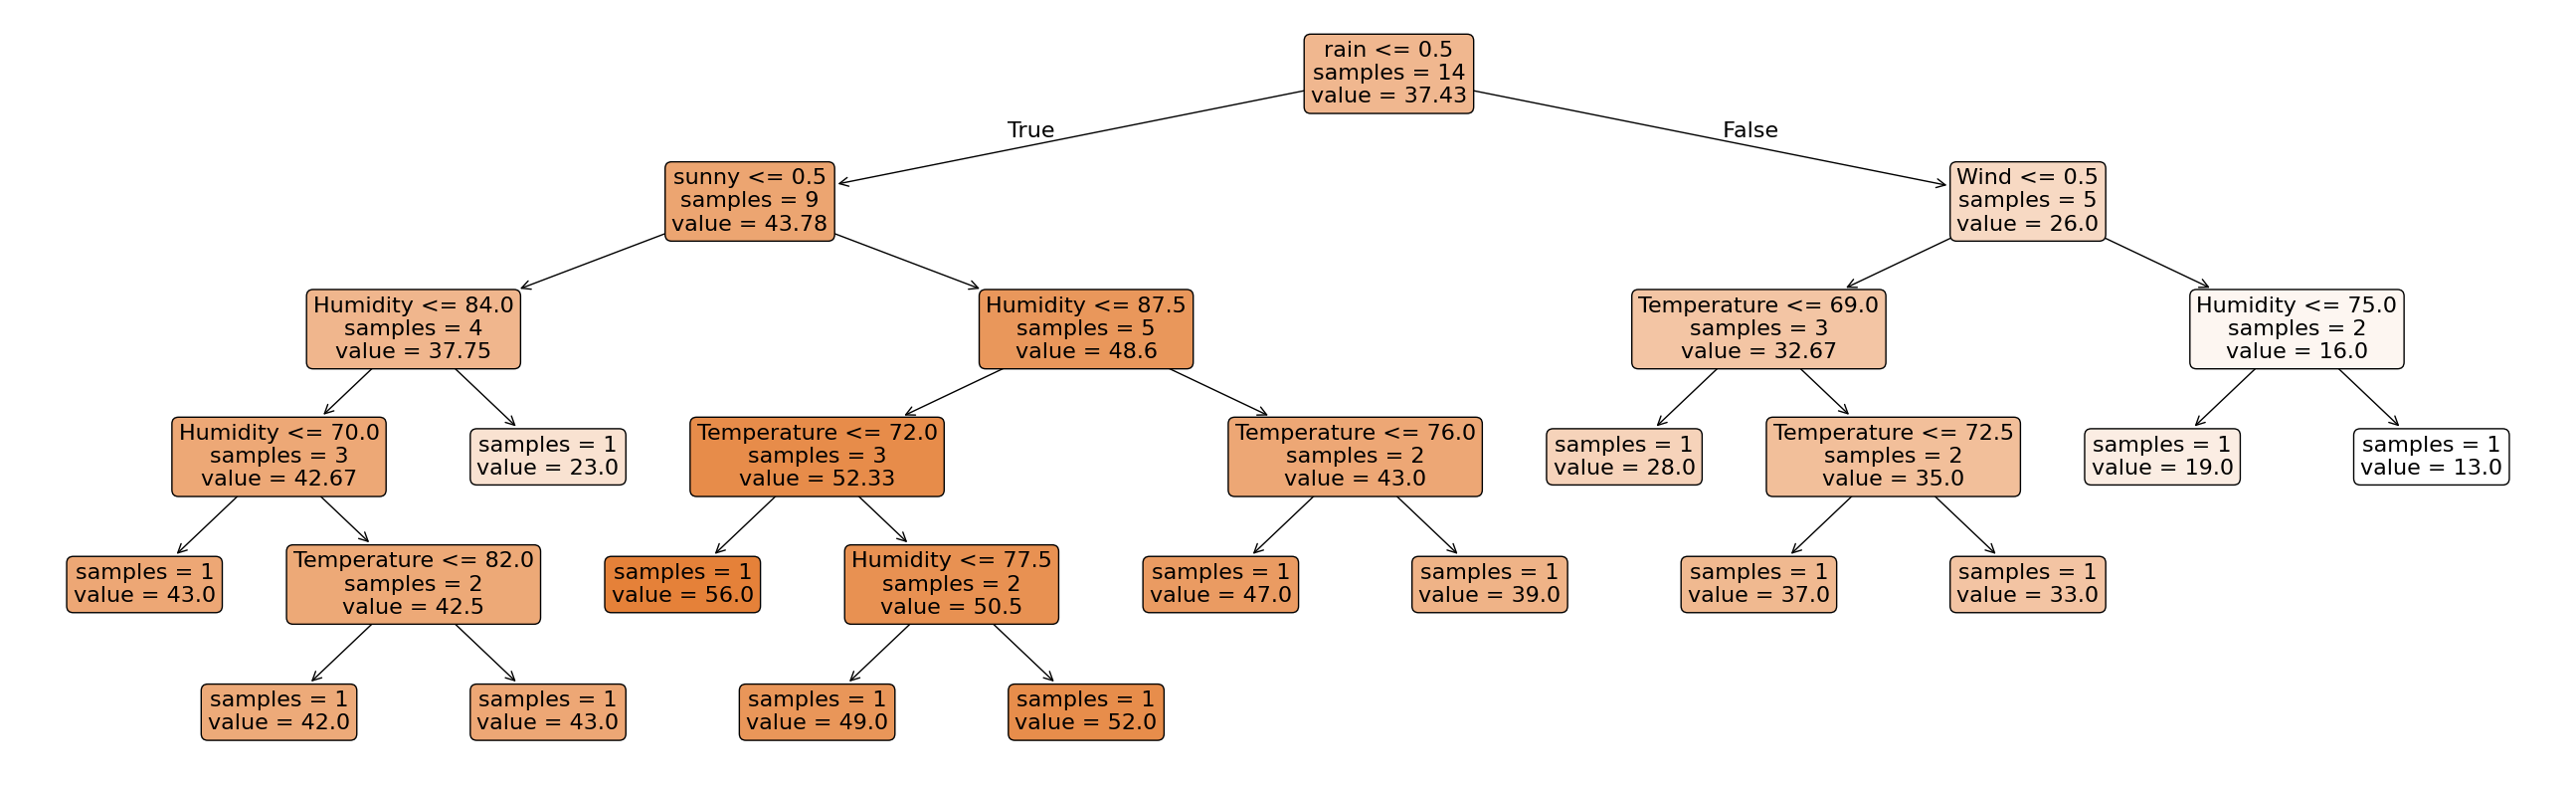

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# Train the model
regr = DecisionTreeRegressor(random_state=42)
regr.fit(X_train, y_train)

# Make predictions
y_pred = regr.predict(X_test)

# Calculate and print RMSE

rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse:.4f}")

# Visualize the decision tree
plt.figure(figsize=(26,8))
plot_tree(regr, feature_names=X.columns, filled=True, rounded=True, impurity=False, fontsize=16, precision=2)
plt.tight_layout()
plt.show()

## Pruning
  * ### Pre-pruning: Halt the growth of the tree during the training process, to prevent a bushy (complex) tree that may overfit. Common techniques:
    * Max. depth
    * Minimum samples for split &mdash; requiring a minimum number of samples to justify splitting a node
    * Minimum samples per leaf &mdash; ensuring each leaf has at least a certain number of samples
    * Maximum number of leaf nodes &mdash; Resrticting the total number of leaves in the tree
    * Minimum impurity decrease &mdash; Only allowing splits that decrease impurity by a specified amount.
  * ### Post-pruning: First build a complete tree. Then remove or collalpse branches that do not significantly contribute to the model's performance. One common technique:
    * Cost Complexity Pruning
      * Step 1 &mdash; Calculate the impurity (mis-classification rate) for each node and sort the values.
      * Step 2 &mdash; The goal is to turn interim nodes into leaves, starting with the leaf with smallest MSE.
      * Step 3 &mdash; For each subtree T, calculate total leaf impurity R(T).   
      
  * **$R(T)$**: The total Mean Squared Error (MSE) of the terminal nodes.
* **$|T|$**: The number of terminal nodes (leaves) in the tree $T$.
     



  * Step 4 &mdash; Compute Cost function for each subtree T.
      Cost(T) = R(T) + α ⋅ |T|
  * Step 5 &mdash; Select the Alpha. The subtree with the smallest cost will be the final tree. Scikit-learn can produce the smallest value of α to obtain a particular subtree. This is called *effective* α.

  * **$\alpha$**: The complexity parameter.
    * If $\alpha = 0$, the tree remains unpruned (maximum complexity).
    * As $\alpha$ increases, the penalty for having more leaves grows, leading to smaller, simpler trees.

By traversing different values of $\alpha$, we can find the 'elbow' where the validation error is minimized.
  * Step 5 &mdash; Run the Decision Tree Regressor with Cost Complexity Pruning.

In [ ]:
# Compute the cost-complexity pruning path
tree = DecisionTreeRegressor(random_state=42)
effective_alphas = tree.cost_complexity_pruning_path(X_train, y_train).ccp_alphas
impurities = tree.cost_complexity_pruning_path(X_train, y_train).impurities

# Function to count leaf nodes
count_leaves = lambda tree: sum(tree.tree_.children_left[i] == tree.tree_.children_right[i] == -1 for i in range(tree.tree_.node_count))

# Train trees and count leaves for each complexity parameter
leaf_counts = [count_leaves(DecisionTreeRegressor(random_state=0, ccp_alpha=alpha).fit(X_train, y_train)) for alpha in effective_alphas]

# Create DataFrame with analysis results
pruning_analysis = pd.DataFrame({
    'total_leaf_impurities': impurities,
    'leaf_count': leaf_counts,
    'cost_function': [f"{imp:.3f} + {leaves}α" for imp, leaves in zip(impurities, leaf_counts)],
    'effective_α': effective_alphas
})

print(pruning_analysis)

    total_leaf_impurities  leaf_count cost_function  effective_α
0                0.000000          14   0.000 + 14α     0.000000
1                0.047619          12   0.048 + 12α     0.023810
2                0.369048          11   0.369 + 11α     0.321429
3                0.940476          10   0.940 + 10α     0.571429
4                2.226190           9    2.226 + 9α     1.285714
5                3.666667           8    3.667 + 8α     1.440476
6                5.952381           7    5.952 + 7α     2.285714
7                8.285714           6    8.286 + 6α     2.333333
8               15.752381           5   15.752 + 5α     7.466667
9               55.158730           3   55.159 + 3α    19.703175
10              78.968254           2   78.968 + 2α    23.809524
11             151.530612           1  151.531 + 1α    72.562358


In [ ]:
# Train the final tree with the chosen alpha
final_tree = DecisionTreeRegressor(random_state=42, ccp_alpha=0.1)
final_tree.fit(X_train, y_train)

# Make predictions
y_pred = final_tree.predict(X_test)

# Calculate and print RMSE
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse:.4f}")

RMSE: 5.4917


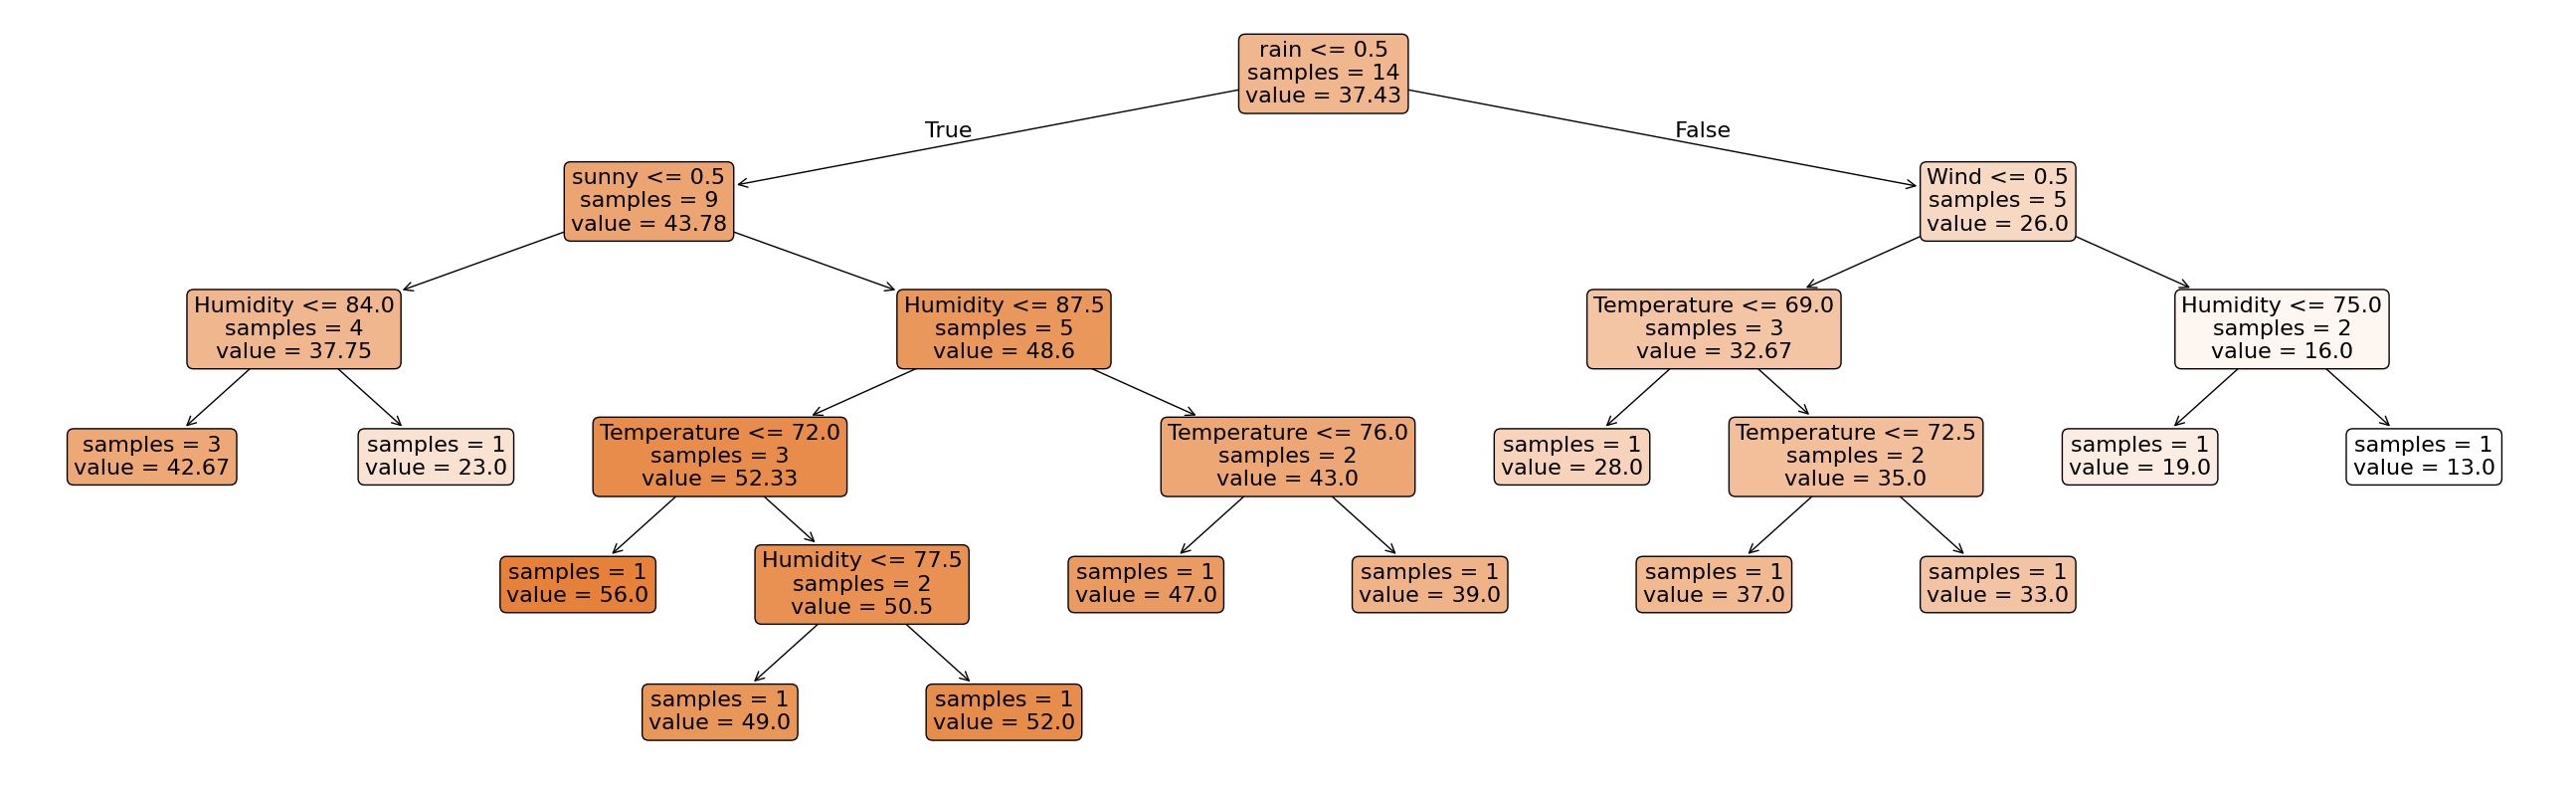

In [ ]:
# Visualize the decision tree
plt.figure(figsize=(26,8))
plot_tree(final_tree, feature_names=X.columns, filled=True, rounded=True, impurity=False, fontsize=16, precision=2)
plt.tight_layout()
plt.show()

## Decision Tree Summary

### Pros

  * No feature scaling needed
  * Model nonlinear relationships
  * Can do both classification and regression
  * Robust
  * Highly interpretable

### Cons

  * Can be expensive to train
  * Often poor predictors - high variance

# Ensemble Methods &mdash; Introduction

* ## Review: Bootstrapping
* ## Bagging &mdash; Bootstrap Aggregation
* ## Random Forest

### Bootstrapping

* What is a bootstrap sample?
  * Given n data points we select a sample of n points with replacement.


* We use bootstrap samples to construct confidence intervals around sample statistics.

  * Example: get a confidence interval around sample median

    * Take 1000 bootstrap samples.
    * Take the median of each sample.
    * The 95% confidence inverval for the median is between the 25th and 975th largest samples.


### Bagging &mdash; Bootstrap Aggregation
* We could repeatedly sample from the population, building decision tree models and averaging the results. But we only have one sample.
* Simulate multiple draws from the data by using multiple bootstrap samples.
* Say we have $n$ such samples.
* Train a high variance, low bias DT model on each of the samples.
* Average the results:
  * How much variance can be reduced?
* We are thinking about the population of all possible decision tree models on our data.
* If we take $n$ samples iid from this distribution and average those, the variance goes down by $\sqrt n$.
* Why is the reduction in variance less than $\sqrt n$?
* There is some correlation between models because those are all trained on bootstrap samples from the same data.

# Random Forests

* Random Forests improve on Bagging by de-correlating the trees using a technique called Subspace Sampling.

* At each decision tree split, only $m$
 (often m = $\sqrt n$
) features are considered.

### Random Forest Parameters
  * Total number of trees
  * Number of features to use at each split
  * Individual decsion tree parameters
    * E.g., Tree Depth, Pruning, Split criterion

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.special import comb

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import log_loss, make_scorer
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.datasets import load_breast_cancer, load_iris

## Ensembles: Intuition

Suppose we have 5 *independent* binary classifiers (they only give 0 or 1 probability). If they are each  70% accurate, what's the accuracy of an ensemble of them?

**Question:** what does independent mean?

In [ ]:
def find_ensemble_accuracy(n, p):
    '''Given a n independent classifiers each of p accuracy,
    return the emsumble accuracy'''
    ensemble_accuracy = 0
    for k in range((n + 1) // 2, n+1):
        ensemble_accuracy += comb(n, k) * p**k * (1-p)**(n-k)
    return ensemble_accuracy

In [ ]:
find_ensemble_accuracy(5, 0.7)

np.float64(0.8369199999999999)

$$ \binom{5}{5} 0.7^5 + \binom{5}{4} 0.7^4 0.3 + \binom{5}{3} 0.7^3 0.3^2 \approx 0.83 $$

With 55 such classifiers we can achieve 99.9% accuracy.


**Question:** what's the limitation?

## How to Make The Trees Independent?

If the learners are all the same, ensembles do not help.

Train each learner on a different subset of data.

**Question:** Why is this better than a single good model?

### Bias and Variance

**Question:** what is bias?

**Question:** what is variance?

**Question:** what is the bias of an unpruned decision tree?

### Compare a Decision Tree with a Random Forest
* Let's investigate the accuracy of a Random Forest compared with a single decision tree, using the Breast Cancer dataset.

In [ ]:
# Load Breast Cancer data
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

X = X.drop(['worst concave points', 'mean concave points', 'worst perimeter', 'worst radius', 'worst area', 'mean concavity'], axis=1)
# Split into test/train
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=.33,
                                                    random_state=0)

In [ ]:
X_train.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean symmetry',
       'mean fractal dimension', 'radius error', 'texture error',
       'perimeter error', 'area error', 'smoothness error',
       'compactness error', 'concavity error', 'concave points error',
       'symmetry error', 'fractal dimension error', 'worst texture',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst symmetry', 'worst fractal dimension'],
      dtype='object')

In [ ]:
# Parameter Search
model = DecisionTreeClassifier()

depth_parm = np.arange(1, 12, 1)
num_samples_parm = np.arange(5,95,10)
parameters = {'max_depth' : depth_parm,
             'min_samples_leaf' : num_samples_parm}

scorer = make_scorer(log_loss,
                     greater_is_better=False) # Removed needs_proba=True
clf = GridSearchCV(model,
                   parameters,
                   cv=10,
                   scoring=scorer)
clf.fit(X_train,y_train)
print(f"log loss = {-clf.score(X_test, y_test)}")
print(f"accuracy = {(clf.predict(X_test) == y_test).mean()}")

log loss = 3.834431211608208
accuracy = 0.8936170212765957


In [ ]:
clf.best_estimator_

DecisionTreeClassifier(max_depth=np.int64(2), min_samples_leaf=np.int64(5))

In [ ]:
# Train and fit model
rf = RandomForestClassifier(n_estimators=1000,
                           max_features='sqrt', # Changed 'auto' to 'sqrt'
                           random_state=0)
rf.fit(X_train, y_train)

# Test Prediction
pred = rf.predict(X_test)
print(f"log loss = {log_loss(y_test, rf.predict_proba(X_test)[:, 1])}")
print(f"accuracy = {rf.score(X_test, y_test)}")

log loss = 0.13907499542185284
accuracy = 0.9521276595744681


### Pros and Cons of Random Forest

Pros

 * Often give near state-of-the-art performance
 * Good out-of-the-box performance
 * No feature scaling needed
 * Model nonlinear relationships

Cons

 * Can be expensive to train (though can be done in parallel)
 * Not interpretable

## Feature Importance

One of the challenges of random forests is the lack of interpretability.

Feature importances are a measure of which features actually effect the predictions.

This can be a critical business question. For example, with churn analysis, it's generally more important to understand *why* customers are churning than to predict which customers are going to churn.

How should we measure it?

<Axes: >

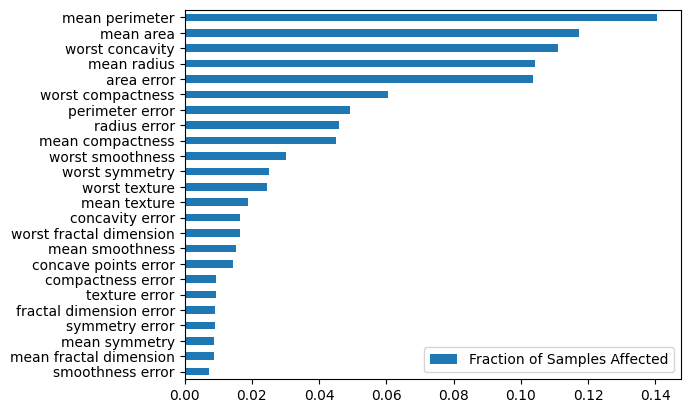

In [ ]:
# Plot the feature importance
feat_scores = pd.DataFrame({'Fraction of Samples Affected' : rf.feature_importances_},
                           index=X.columns)
feat_scores = feat_scores.sort_values(by='Fraction of Samples Affected')
feat_scores.plot(kind='barh')

### Feature Importance in Random Forest

Random Forest provides a built-in mechanism to rank the importance of features. The most common methods are:

#### 1. Mean Decrease in Impurity (MDI)
For each decision tree, the nodes are split using a specific feature that maximizes the reduction in impurity (Gini or Variance).
* **Calculation:** The importance is the sum of all impurity decreases in the forest due to a particular feature, normalized by the total number of trees.
* **Note:** This method can be biased toward high-cardinality features (features with many unique values).

#### 2. Permutation Feature Importance (MDI)
This is a model-agnostic technique that is often more reliable.
* **Calculation:** After training the model, the values of a single feature are randomly shuffled. The decrease in the model's score (e.g., R-squared or Accuracy) is measured.
* A large drop in score indicates the feature is vital for the model's predictive power.

# Lecture 3
## Ensemble Methods
  * ### Bootstrapping
  * ### Bagging &mdash; Bootstrapped Aggregation
  * ### Random Forest
    * #### Feature Importance
  * ### Boosting (Next Lecture)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.special import comb


from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import root_mean_squared_error, log_loss, make_scorer
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer, load_iris


## An Experiment

You're each going to be a decision tree on some data based on a bootstrap sample, and then we'll all ensemble the results.

In [ ]:
data = load_iris()

# Split into test/train, using the same random state for everyone
X_train, X_test, y_train, y_test = train_test_split(data.data,
                                                    data.target,
                                                    random_state=462) ## Change this ##

In [ ]:
clf = DecisionTreeClassifier()
# each of you has a different bootstrap sample
bootstrap_sample = np.random.choice(range(len(X_train)),
                                    len(X_train),
                                    replace=True)
clf.fit(X_train[bootstrap_sample], y_train[bootstrap_sample])

DecisionTreeClassifier()

### The Bootstrap process:

*len(X_train)*: This gets the number of samples (rows) in your training dataset X_train.

*range(len(X_train))*: This creates a sequence of numbers from 0 up to (but not including) the number of samples in X_train.

These numbers represent the indices of the rows in X_train.
np.random.choice(...): This is a NumPy function that randomly selects elements from a given array or sequence.

*size=len(X_train)* specifies that we want to select the same number of elements as there are samples in X_train.

*replace=True*: This is the crucial part of bootstrapping. It means that when selecting elements, we allow for sampling with replacement. This means that a single row index can be selected multiple times in the bootstrap_sample.

In summary, this line of code is creating a new sample of row indices for your training data. This new sample (bootstrap_sample) has the same size as the original training data, but it's created by randomly picking indices from the original training data with replacement.

This results in a new dataset (when you use these indices to select rows from X_train and y_train) that is a resampled version of the original training data, where some original samples may appear multiple times and others may not appear at all.

This is the core idea behind bootstrapping, which is used here to create different training sets for the Decision Tree Classifier to evaluate its stability and estimate the variability of its performance.

In [ ]:
print("Accuracy = {:.3f}".format(np.mean(clf.predict(X_test) == y_test)))

Accuracy = 0.921


In [ ]:
print("My prediction: {}".format(clf.predict(X_test)[0:20]))
print("Actual result: {}".format(y_test[0:20]))

My prediction: [0 2 0 1 1 1 2 2 0 2 2 0 1 2 2 1 1 2 1 0]
Actual result: [0 2 0 1 2 1 2 2 0 2 2 0 1 2 2 2 1 2 1 0]


What is your prediction?

This concept, creating each model from a bootstrap sample and aggregating the results, is called ????. It could really be used with any sort of model, but is generally done with decision trees.

**Question:** why?

## Bagged Regression Trees

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler

# Create dataset
dataset_dict = {
    'Outlook': ['sunny', 'sunny', 'overcast', 'rain', 'rain', 'rain', 'overcast', 'sunny', 'sunny', 'rain', 'sunny', 'overcast', 'overcast', 'rain', 'sunny', 'overcast', 'rain', 'sunny', 'sunny', 'rain', 'overcast', 'rain', 'sunny', 'overcast', 'sunny', 'overcast', 'rain', 'overcast'],
    'Temperature': [85.0, 80.0, 83.0, 70.0, 68.0, 65.0, 64.0, 72.0, 69.0, 75.0, 75.0, 72.0, 81.0, 71.0, 81.0, 74.0, 76.0, 78.0, 82.0, 67.0, 85.0, 73.0, 88.0, 77.0, 79.0, 80.0, 66.0, 84.0],
    'Humidity': [85.0, 90.0, 78.0, 96.0, 80.0, 70.0, 65.0, 95.0, 70.0, 80.0, 70.0, 90.0, 75.0, 80.0, 88.0, 92.0, 85.0, 75.0, 92.0, 90.0, 85.0, 88.0, 65.0, 70.0, 60.0, 95.0, 70.0, 78.0],
    'Wind': [False, True, False, False, False, True, True, False, False, False, True, True, False, True, True, False, False, True, False, True, True, False, True, False, False, True, False, False],
    'Num_Players': [52,39,43,37,28,19,43,47,56,33,49,23,42,13,33,29,25,51,41,14,34,29,49,36,57,21,23,41]
}

df = pd.DataFrame(dataset_dict)

# One-hot encode 'Outlook' column
df = pd.get_dummies(df, columns=['Outlook'], prefix='', prefix_sep='', dtype=int)

# Convert 'Wind' column to binary
df['Wind'] = df['Wind'].astype(int)

# Split data into features and target, then into training and test sets
X, y = df.drop(columns='Num_Players'), df['Num_Players']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5, shuffle=False)

# Scale the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize Decision Tree Regressor
tree = DecisionTreeRegressor(random_state=42)


# Train the tree
fit_tree = tree.fit(X_train, y_train)

# Make predictions
y_pred = fit_tree.predict(X_test)

# Calculate and print RMSE
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse:.4f}")

RMSE: 5.2712


In [4]:
n_bootstrap_runs = 1000
rmse_values = []

for _ in range(n_bootstrap_runs):
    # Perform Bootstrapping and Model Training
    bootstrap_sample = np.random.choice(range(len(X_train)),
                                        len(X_train),
                                        replace=True)
    tree.fit(X_train.iloc[bootstrap_sample], y_train.iloc[bootstrap_sample])

    # Make Predictions and Calculate RMSE
    y_pred_bootstrap = tree.predict(X_test)
    rmse_bootstrap = root_mean_squared_error(y_test, y_pred_bootstrap)

    # Store RMSE values
    rmse_values.append(rmse_bootstrap)

# Store and Analyze RMSE Values
mean_rmse = np.mean(rmse_values)
std_rmse = np.std(rmse_values)

### The Bootstrap process:

*len(X_train)*: This gets the number of samples (rows) in your training dataset X_train.

*range(len(X_train))*: This creates a sequence of numbers from 0 up to (but not including) the number of samples in X_train.

These numbers represent the indices of the rows in X_train.
np.random.choice(...): This is a NumPy function that randomly selects elements from a given array or sequence.

*size=len(X_train)* specifies that we want to select the same number of elements as there are samples in X_train.

*replace=True*: This is the crucial part of bootstrapping. It means that when selecting elements, we allow for sampling with replacement. This means that a single row index can be selected multiple times in the bootstrap_sample.

In summary, this line of code is creating a new sample of row indices for your training data. This new sample (bootstrap_sample) has the same size as the original training data, but it's created by randomly picking indices from the original training data with replacement.

This results in a new dataset (when you use these indices to select rows from X_train and y_train) that is a resampled version of the original training data, where some original samples may appear multiple times and others may not appear at all.

This is the core idea behind bootstrapping, which is used here to create different training sets for the Decision Tree Regressor to evaluate its stability and estimate the variability of its performance.

In [5]:
# Report Results
print(f"Mean RMSE over {n_bootstrap_runs} bootstrap runs: {mean_rmse:.4f}")
print(f"Standard deviation of RMSE over {n_bootstrap_runs} bootstrap runs: {std_rmse:.4f}")

Mean RMSE over 1000 bootstrap runs: 9.7734
Standard deviation of RMSE over 1000 bootstrap runs: 2.1073


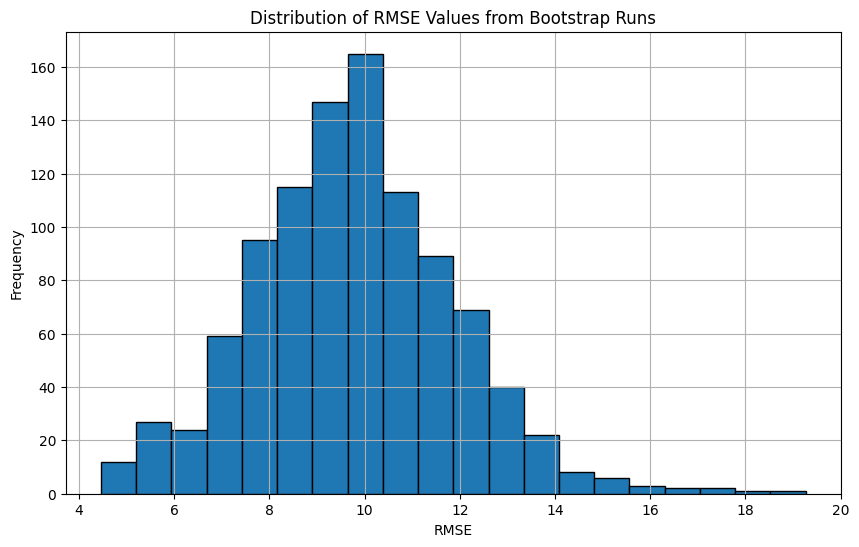

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(rmse_values, bins=20, edgecolor='black')
plt.title('Distribution of RMSE Values from Bootstrap Runs')
plt.xlabel('RMSE')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### Review Random Forest Example &mdash; Breast Cancer Data

In [7]:
# Load Breast Cancer data
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

X = X.drop(['worst concave points', 'mean concave points', 'worst perimeter', 'worst radius', 'worst area', 'mean concavity'], axis=1)
# Split into test/train
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=.33,
                                                    random_state=0)

In [8]:
# Train and fit model
rf = RandomForestClassifier(n_estimators=1000,
                           max_features='sqrt',
                           random_state=0)
rf.fit(X_train, y_train)

# Test Prediction
pred = rf.predict(X_test)
print(f"log loss = {log_loss(y_test, rf.predict_proba(X_test)[:, 1])}")
print(f"accuracy = {rf.score(X_test, y_test)}")

log loss = 0.13907499542185284
accuracy = 0.9521276595744681


### Out of Bag Error

The out-of-bag error is a way to measure the error of a bagged model (including random forests).

Since the decision trees are constructed from a bootstrap sample, each tree will (probably) not see all of the data, so each datum will (probably) not be seen by many of the trees.

In [9]:
n_bootstrap_runs = 50
oob_errors = [] # List to store OOB errors

for _ in range(n_bootstrap_runs):
    # Perform Bootstrapping
    bootstrap_sample_indices = np.random.choice(range(len(X_train)),
                                                len(X_train),
                                                replace=True)

    # Identify Out-of-Bag samples
    oob_sample_indices = np.array([j for j in range(len(X_train)) if j not in bootstrap_sample_indices])

    # Model Training on Bootstrap Sample
    rf.fit(X_train.iloc[bootstrap_sample_indices], y_train.iloc[bootstrap_sample_indices])

    # Calculate OOB Error (only if there are OOB samples)
    if len(oob_sample_indices) > 0:
        y_true_oob = y_train.iloc[oob_sample_indices]
        y_pred_proba_oob = rf.predict_proba(X_train.iloc[oob_sample_indices])[:, 1]
        oob_error = log_loss(y_true_oob, y_pred_proba_oob)
        oob_errors.append(oob_error)

# Calculate the mean OOB error
mean_oob_error = np.mean(oob_errors) if oob_errors else 0

print(f"Mean OOB Error over {n_bootstrap_runs} bootstrap runs: {mean_oob_error:.4f}")

Mean OOB Error over 50 bootstrap runs: 0.1615


O-O-B is a way to estimate proportion of cases where the Classifier (Random Forest) is wrongly classifying the unseen data. It is a way of validation without explicitly using a separate validation dataset.

## Revisit Feature Importance

## Feature Importances: Average Decrease in Impurity

How much does each feature decrease the impurity (that is, how much does each feature contribute to information gain, on average)? (Described [here](https://www.stat.berkeley.edu/~breiman/RandomForests/cc_home.htm#giniimp))

 * For each tree, each split is made in order to reduce the total impurity of the tree (Gini/entropy/MSE).
 * "Total information gain" for a single tree is the sum of the information gain at each split, and a feature's importance for a single tree is the total information gain of splits involving that feature divided by the total information gain of the tree.
 * This is called **Gini importance** and it is how `sklearn` calculates feature importance.
 * The importance of a feature in a forest is the average of the Gini importances for that feature across all trees.

In [10]:
rf = RandomForestClassifier(n_estimators=1000,
                           max_features='sqrt',
                           random_state=0,
                           oob_score=True)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=1000, oob_score=True, random_state=0)

In [11]:
rf.oob_score_

0.952755905511811

Text(0.5, 0, 'Average contribution to information gain')

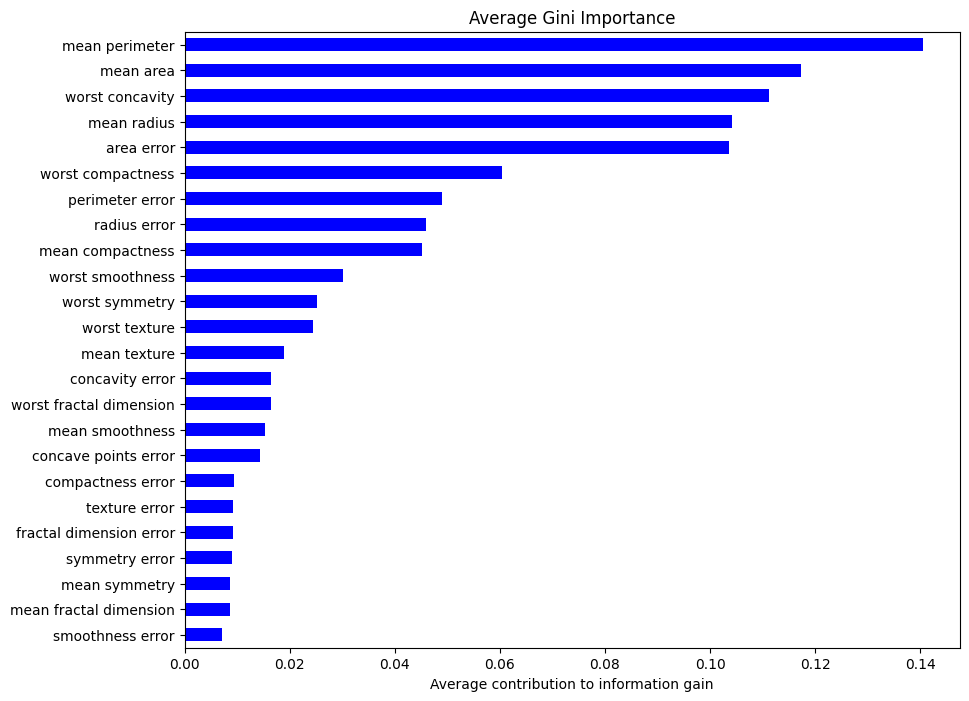

In [12]:
# Plot the feature importance
feat_scores = pd.Series(rf.feature_importances_,
                           index=X.columns)
feat_scores = feat_scores.sort_values()
ax = feat_scores.plot(kind='barh',
                      figsize=(10,8),
                      color='b')
ax.set_title('Average Gini Importance')
ax.set_xlabel('Average contribution to information gain')

## Feature Importances: Average Decrease in test (OOB) score when a feature's values are shuffled

(Described [here](https://www.stat.berkeley.edu/~breiman/RandomForests/cc_home.htm#varimp))

How much does randomly shuffling the values of a feature affect performance (say, accuracy score)?

To compute the importance of the $j^{th}$ feature:

 * When the $b^{th}$ tree is grown, use it to predict the OOB samples and record the score (accuracy, for example).
 * Scramble the values of the $j^{th}$ feature in the OOB samples and do the prediction again.  Compute the new (lower) score.
 * Average the decrease in score across all trees.


### Define a function to calculate oob score

#### Subtask:
Create a function that takes the trained Random Forest model, the training features (X_train), and the training target (y_train) as input, and returns the Out-of-Bag (OOB) score.


In [13]:
def calculate_oob_score(model, X_train, y_train):
    """
    Calculates the Out-of-Bag (OOB) score for a Random Forest model.

    Args:
        model: A Random Forest model (either RandomForestRegressor or RandomForestClassifier).
        X_train: Training features (pandas DataFrame).
        y_train: Training target (pandas Series).

    Returns:
        The OOB score of the fitted model.
    """
    model.oob_score = True  # Ensure oob_score is enabled
    model.fit(X_train, y_train)
    return model.oob_score_

### Calculate baseline oob score

Calculate the OOB score of the model with the original training data.

In [14]:
baseline_oob_score = calculate_oob_score(rf, X_train, y_train)
print(f"Baseline OOB Score: {baseline_oob_score:.4f}")

Baseline OOB Score: 0.9528


### Iterate through features


For each feature in the training data, shuffle its values, train the model on the modified data, calculate the OOB score, and store the decrease in OOB score compared to the baseline.


In [15]:
oob_score_decreases = []

for column in X_train.columns:
    X_train_shuffled = X_train.copy()
    X_train_shuffled[column] = X_train_shuffled[column].sample(frac=1, random_state=42).reset_index(drop=True)

    # Train the model on the shuffled data
    rf.fit(X_train_shuffled, y_train)

    # Calculate the OOB score of the model trained on the shuffled data
    shuffled_oob_score = rf.oob_score_

    # Calculate the decrease in OOB score
    oob_score_decrease = baseline_oob_score - shuffled_oob_score

    # Append the decrease to the list
    oob_score_decreases.append(oob_score_decrease)

### Calculate average decrease in oob score


Calculate the average decrease in OOB score for each feature over multiple runs.

In [16]:
oob_score_decreases_series = pd.Series(oob_score_decreases, index=X_train.columns)
mean_oob_score_decreases = oob_score_decreases_series.mean()

### Display feature importance

Display the average decrease in OOB score for each feature, sorted in descending order.

In [17]:
oob_score_decreases_series_sorted = oob_score_decreases_series.sort_values(ascending=False)
print("Average decrease in OOB score (Feature Importance):")
print(oob_score_decreases_series_sorted)

Average decrease in OOB score (Feature Importance):
fractal dimension error    0.007874
mean texture               0.005249
mean compactness           0.005249
mean area                  0.005249
smoothness error           0.005249
compactness error          0.005249
texture error              0.005249
worst concavity            0.005249
worst symmetry             0.005249
worst smoothness           0.002625
mean smoothness            0.002625
mean perimeter             0.002625
mean radius                0.002625
worst texture              0.002625
concavity error            0.002625
radius error               0.002625
area error                 0.002625
symmetry error             0.002625
perimeter error            0.000000
mean symmetry              0.000000
worst compactness         -0.002625
concave points error      -0.002625
worst fractal dimension   -0.002625
mean fractal dimension    -0.005249
dtype: float64


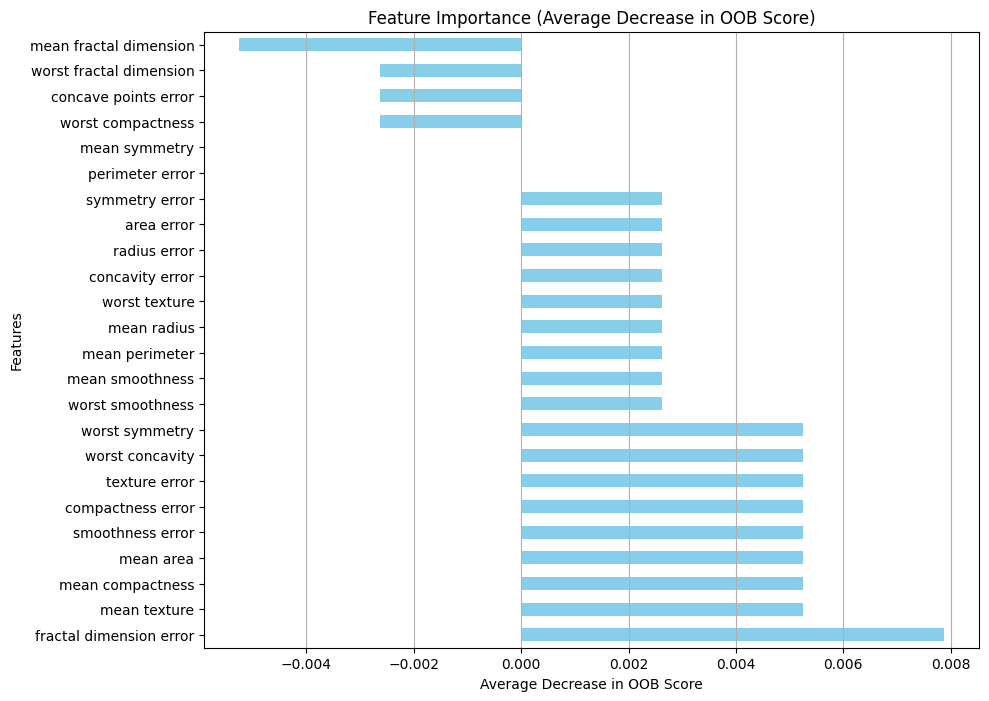

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
oob_score_decreases_series_sorted.plot(kind='barh', color='skyblue')
plt.title('Feature Importance (Average Decrease in OOB Score)')
plt.xlabel('Average Decrease in OOB Score')
plt.ylabel('Features')
plt.grid(axis='x')
plt.show()


### Key Findings

*   The baseline Out-of-Bag (OOB) score for the trained Random Forest model on the original data was calculated as 0.9528.
*   The average decrease in OOB score was calculated for each feature by shuffling its values and retraining the model.

*   The calculated average decrease in OOB score for each feature represents its importance to the model's performance; features with a larger decrease are more important.

# Lecture 4
## Ensemble Methods
  * ## Boosting
    * ### Motivation

### Linear Algebra Review

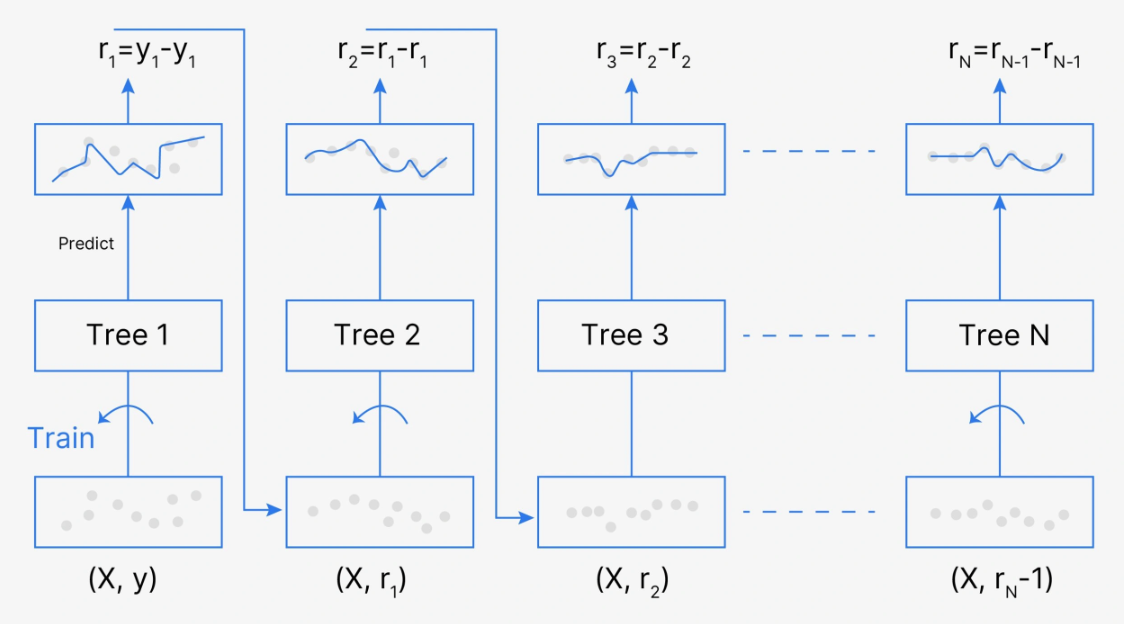

### High-level idea behind Gradient Boosting
Gradient Boosting is a powerful machine learning technique used for both classification and regression tasks. It builds a model in a stage-wise fashion, and it generalizes them by allowing optimization of an arbitrary differentiable loss function.

Here's a breakdown of the core idea:

Start with a simple model: You begin with a basic model (often a decision tree, but a very simple one, sometimes just the average of the target variable) that makes initial predictions.

Calculate the "residuals" (errors): You then look at the difference between the actual target values and the predictions made by the current model. These differences are called residuals (or errors).

Train a new model on the residuals: Instead of training the next model on the original target variable, you train it on the residuals from the previous step. This new model learns to correct the errors made by the previous one.

Add the new model's predictions to the ensemble: You add the predictions of this new model (scaled by a small learning rate) to the predictions of the previous models. This creates a slightly improved ensemble model.

Repeat: You repeat steps 2-4 for a specified number of iterations or until the residuals are small enough. Each new model focuses on correcting the remaining errors.

**Key Concepts:**

*Weak Learners*: Gradient Boosting typically uses "weak learners," which are models that perform slightly better than random chance (like shallow decision trees).

The power comes from combining many of these weak learners.


*Gradient Descent*: The "gradient" part of the name comes from the fact that the process of training new models on residuals is analogous to gradient descent, where you iteratively move in the direction that minimizes the loss function.

*Loss Function*: Gradient Boosting can optimize different loss functions, making it versatile for various tasks.


### The Math of Gradient Boosting

The core idea is to iteratively build an ensemble of weak learners (typically decision trees) to minimize a loss function. The key is that each new weak learner is trained to predict the negative gradient of the loss function with respect to the predictions of the current ensemble. This is where the "gradient" in Gradient Boosting comes from.

Here's a simplified breakdown of the process for a regression problem with Mean Squared Error (MSE) as the loss function:

Let $F_0(x)$
 be the initial model, which is often just the average of the target variable $y$.

$F_0(x) = \text{average}(y)$

For each iteration $m$ from 1 to $M$ (where $M$ is the number of weak learners):

Calculate the "pseudo-residuals": For each training sample $(x_i, y_i)$, calculate the negative gradient of the loss function with respect to the current ensemble's prediction $F_{m-1}(x_i)$.

For MSE, the loss function is $L(y, F(x)) = \frac{1}{2}(y - F(x))^2$. The negative gradient is:

$g_i = - \left[ \frac{\partial L(y_i, F_{m-1}(x_i))}{\partial F_{m-1}(x_i)} \right] = - \left[ \frac{\partial \frac{1}{2}(y_i - F_{m-1}(x_i))^2}{\partial F_{m-1}(x_i)} \right] = - [-(y_i - F_{m-1}(x_i))] = y_i - F_{m-1}(x_i)$


These $g_i$ values are essentially the residuals (the difference between the actual value and the current prediction).


In the context of Gradient Boosting, these are called "pseudo-residuals" because for other loss functions, the negative gradient might not be simply the residual.

Train a weak learner on the pseudo-residuals: Train a new weak learner, denoted as $h_m(x)$, to predict the pseudo-residuals $g_i$ using the training data $x_i$.

Calculate the multiplier (or step size): Determine a multiplier $\gamma_m$ for the weak learner $h_m(x)$. This multiplier is calculated to minimize the loss function when adding $\gamma_m h_m(x)$ to the current ensemble.

For some loss functions, there's a closed-form solution for $\gamma_m$. For others, it's found through line search. A common approach for trees is to calculate a separate multiplier for each leaf node.

Update the ensemble: Update the ensemble model by adding the new weak learner's prediction, scaled by the learning rate ($\nu$) and the multiplier ($\gamma_m$):

$F_m(x) = F_{m-1}(x) + \nu \cdot \gamma_m \cdot h_m(x)$

The learning rate $\nu$ (typically between 0 and 1) controls the step size at each iteration and helps prevent overfitting.

Repeat: Continue steps 1-4 for a specified number of iterations or until a stopping criterion is met.

For other loss functions:

The process is similar, but the calculation of the pseudo-residuals (the negative gradient) will change according to the specific loss function. The multiplier calculation might also become more complex.

In essence, Gradient Boosting works by repeatedly identifying the directions of steepest descent in the loss function (the negative gradients) and training weak learners to move the ensemble's predictions in those directions to minimize the loss.

### Gradient Boosting Example (Regression)

In [19]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Generate some sample data
X = np.random.rand(100, 1) * 10
y = np.sin(X).ravel() + np.random.normal(0, 0.5, 100)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Gradient Boosting Regressor
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbr.fit(X_train, y_train)

# Make predictions on the test set
y_pred = gbr.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

Mean Squared Error: 0.2487


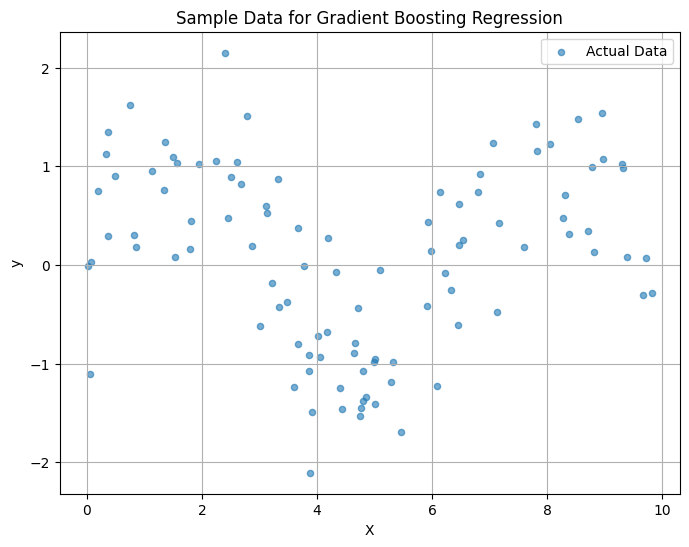

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X, y, s=20, alpha=0.6, label='Actual Data')
# Removed the line plotting GBR predictions
plt.title('Sample Data for Gradient Boosting Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

This example demonstrates the basic steps:

1.  **Import necessary libraries:** `GradientBoostingRegressor` for the model, `train_test_split` for data splitting, `mean_squared_error` for evaluation, and `numpy` for generating sample data.
2.  **Generate sample data:** A simple sinusoidal dataset with some noise is created.
3.  **Split data:** The data is split into training and testing sets.
4.  **Initialize and train the model:** A `GradientBoostingRegressor` is initialized with some common parameters (`n_estimators`, `learning_rate`, `max_depth`) and trained on the training data.
5.  **Make predictions:** Predictions are made on the unseen test data.
6.  **Evaluate the model:** The Mean Squared Error (MSE) is calculated to assess the model's performance.

You can adjust the hyperparameters (`n_estimators`, `learning_rate`, `max_depth`, etc.) to tune the model's performance.

In [21]:
# Calculate residuals
residuals = y_test - y_pred

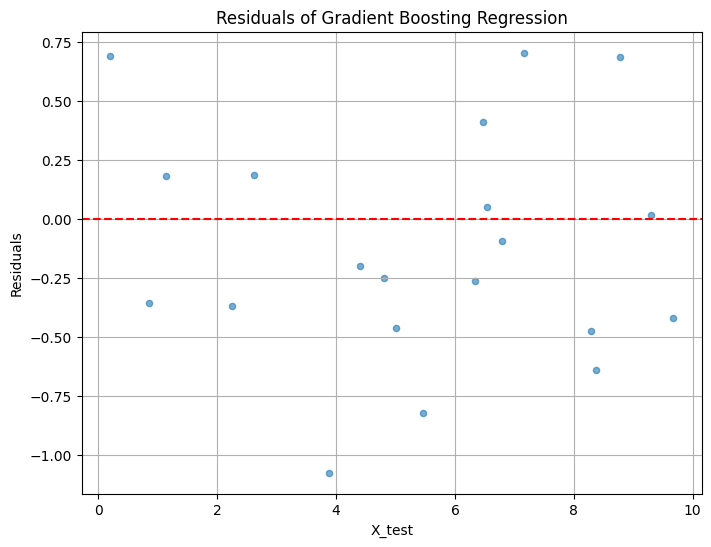

In [22]:
## Plot the residuals

plt.figure(figsize=(8, 6))
plt.scatter(X_test, residuals, s=20, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at 0
plt.title('Residuals of Gradient Boosting Regression')
plt.xlabel('X_test')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

### An Example with Multiple Trees

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler

# Create dataset
dataset_dict = {
    'Outlook': ['sunny', 'sunny', 'overcast', 'rain', 'rain', 'rain', 'overcast', 'sunny', 'sunny', 'rain', 'sunny', 'overcast', 'overcast', 'rain', 'sunny', 'overcast', 'rain', 'sunny', 'sunny', 'rain', 'overcast', 'rain', 'sunny', 'overcast', 'sunny', 'overcast', 'rain', 'overcast'],
    'Temperature': [85.0, 80.0, 83.0, 70.0, 68.0, 65.0, 64.0, 72.0, 69.0, 75.0, 75.0, 72.0, 81.0, 71.0, 81.0, 74.0, 76.0, 78.0, 82.0, 67.0, 85.0, 73.0, 88.0, 77.0, 79.0, 80.0, 66.0, 84.0],
    'Humidity': [85.0, 90.0, 78.0, 96.0, 80.0, 70.0, 65.0, 95.0, 70.0, 80.0, 70.0, 90.0, 75.0, 80.0, 88.0, 92.0, 85.0, 75.0, 92.0, 90.0, 85.0, 88.0, 65.0, 70.0, 60.0, 95.0, 70.0, 78.0],
    'Wind': [False, True, False, False, False, True, True, False, False, False, True, True, False, True, True, False, False, True, False, True, True, False, True, False, False, True, False, False],
    'Num_Players': [52,39,43,37,28,19,43,47,56,33,49,23,42,13,33,29,25,51,41,14,34,29,49,36,57,21,23,41]
}

df = pd.DataFrame(dataset_dict)

# One-hot encode 'Outlook' column
df = pd.get_dummies(df, columns=['Outlook'], prefix='', prefix_sep='', dtype=int)

# Convert 'Wind' column to binary
df['Wind'] = df['Wind'].astype(int)

# Split data into features and target, then into training and test sets
X, y = df.drop(columns='Num_Players'), df['Num_Players']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5, shuffle=False)

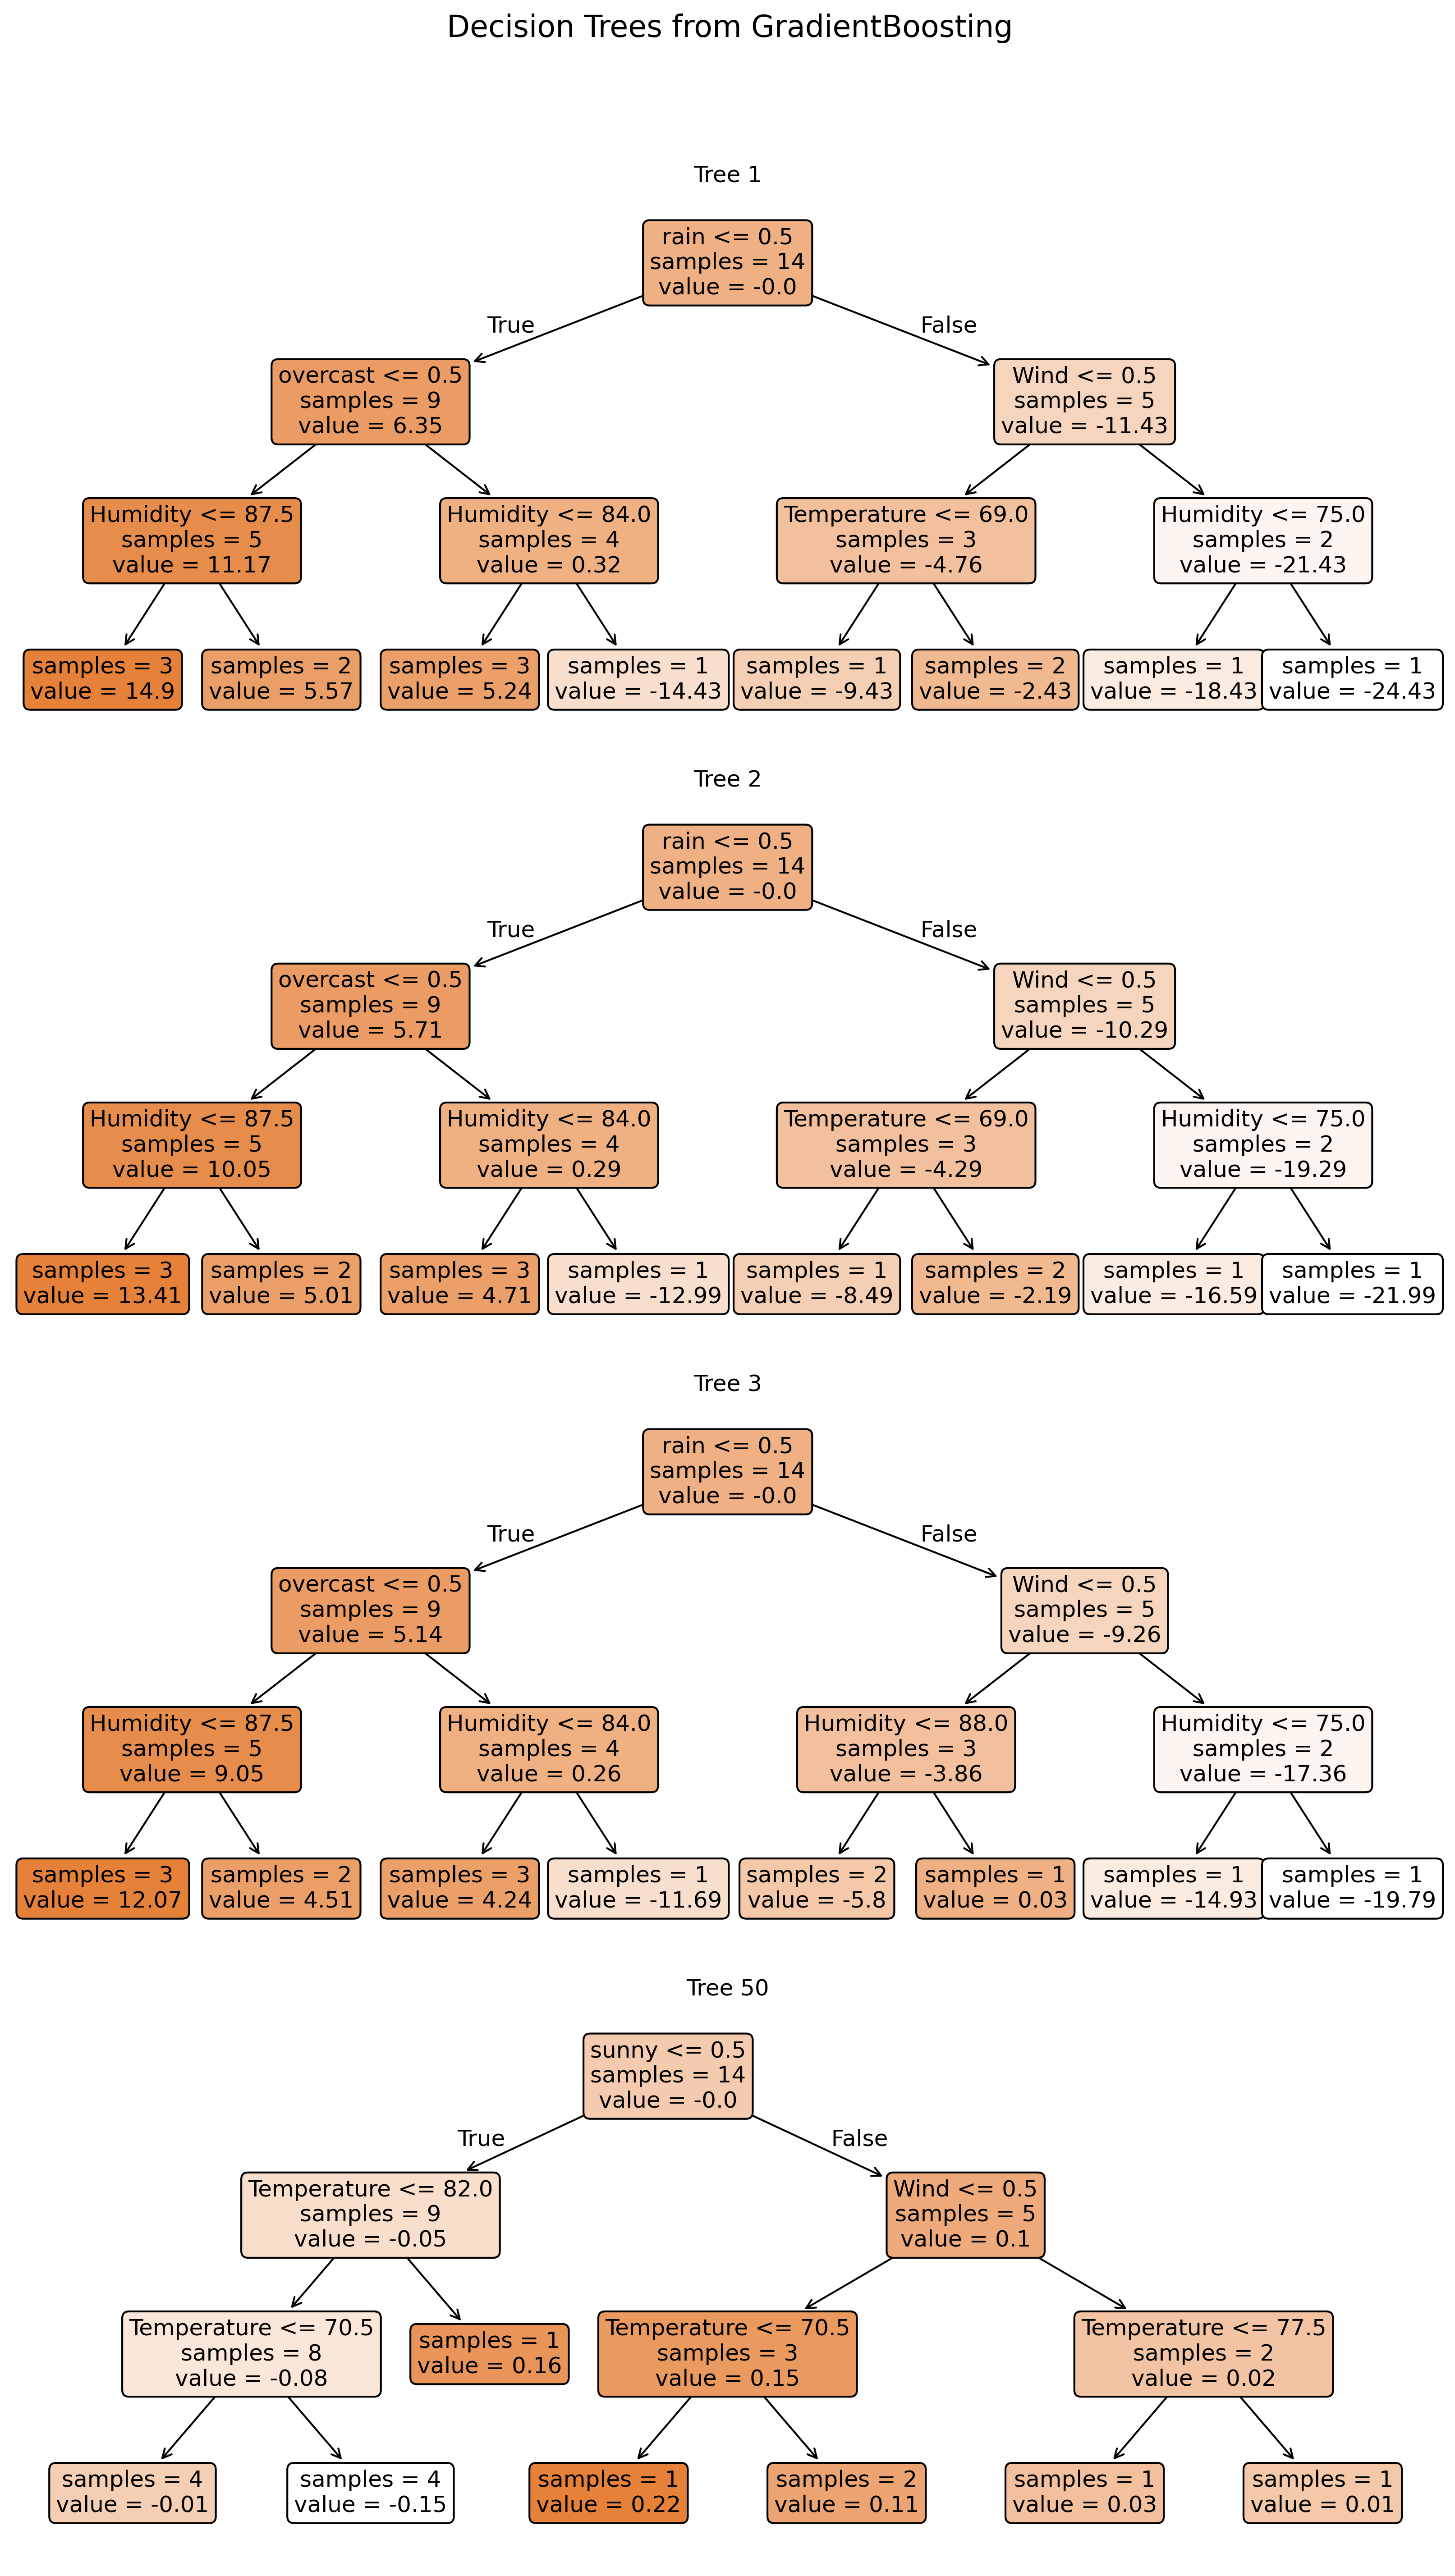

In [24]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor

# Train the model
clf = GradientBoostingRegressor(criterion='squared_error', learning_rate=0.1, random_state=42)
clf.fit(X_train, y_train)

# Plot trees 1, 2, 3, and 50
plt.figure(figsize=(11, 20), dpi=300)

for i, tree_idx in enumerate([0, 1, 2, 49]):
    plt.subplot(4, 1, i+1)
    plot_tree(clf.estimators_[tree_idx,0],
              feature_names=X_train.columns,
              impurity=False,
              filled=True,
              rounded=True,
              precision=2,
              fontsize=12)
    plt.title(f'Tree {tree_idx + 1}')

plt.suptitle('Decision Trees from GradientBoosting', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
!apt-get update
!apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic
!pip install nbconvert pandas

Hit:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,389 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [3,799 kB]
Get:14 http://archive.

## Flavors of Boosting Algorithms
  * ### ADA Boost
  * ### GBM
  * ### LightGBM
  * ### XGBoost



### **AdaBoost** (Adaptive Boosting):

Concept: AdaBoost is one of the earliest boosting algorithms. It works by sequentially training a series of weak learners (typically decision stumps, which are decision trees with only one split).
How it works: In each iteration, AdaBoost focuses on the samples that were misclassified by the previous weak learners. It assigns higher weights to these misclassified samples, making them more important for the next weak learner to get right. The final prediction is a weighted sum of the predictions of all the weak learners, where the weights are determined by the accuracy of each learner.
Key Idea: Adaptively changes the weights of the training samples to focus on difficult-to-classify instances.
Strengths: Relatively simple to understand and implement, can be effective on a variety of problems.
Weaknesses: Can be sensitive to noisy data and outliers, may not perform as well as more modern boosting methods on complex datasets.

**Gradient Boosting** is a more general framework than AdaBoost. Instead of weighting samples, it trains each new weak learner to predict the residuals (or more generally, the negative gradient of the loss function) of the previous ensemble. LightGBM and XGBoost are highly optimized and popular implementations of the Gradient Boosting framework.


Gradient Boosting Machines (including LightGBM and XGBoost).



### **(Extreme Gradient Boosting):**

Concept: XGBoost is a highly efficient and scalable implementation of Gradient Boosting. It's known for its speed and performance.


How it works: XGBoost introduces several enhancements to standard Gradient Boosting, including:
  * Regularization: Includes L1 and L2 regularization to prevent overfitting.
  * Handling Missing Values: Can handle missing values internally.
  * Parallel Processing: Supports parallel processing for faster training.
  * Tree Pruning: Uses a more sophisticated tree pruning method.

Key Idea: Optimized and regularized Gradient Boosting for speed and performance.

Strengths: High accuracy, fast training speed, handles various data types and missing values well, widely used in Kaggle competitions.

Weaknesses: Can be more complex to understand and tune than simpler algorithms.

### **LightGBM (Light Gradient Boosting Machine):**

Concept: LightGBM is another fast and efficient Gradient Boosting framework. It's designed for large datasets and high dimensionality.

How it works: LightGBM uses a novel technique called Gradient-based One-Side Sampling (GOSS) to filter out data instances and a Exclusive Feature Bundling (EFB) to bundle mutually exclusive features.

These techniques significantly speed up training without losing much accuracy.

Key Idea: Optimized for speed and memory usage, especially for large datasets.

Strengths: Very fast training speed, low memory usage, good accuracy, handles large datasets effectively.

Weaknesses: Can be sensitive to hyperparameters, may not perform as well on smaller datasets compared to XGBoost in some cases.


### In summary:

AdaBoost: An older method that weights samples.

XGBoost: A highly optimized and regularized Gradient Boosting implementation known for performance.

LightGBM: A very fast and memory-efficient Gradient Boosting implementation, particularly good for large datasets.
All three are powerful boosting algorithms, and the best choice often depends on the specific dataset and problem.

### Pros and Cons of Gradient Boosting


Gradient Boosting is a powerful technique, but like any algorithm, it has its strengths and weaknesses.

**Pros** of Gradient Boosting:

*High Accuracy*: Gradient Boosting models often achieve state-of-the-art accuracy on a wide range of tasks, especially on structured data. They are very effective at capturing complex non-linear relationships in the data.

*Handles Different Feature Types:* It can handle various types of features (numerical, categorical) and doesn't require extensive feature scaling like some other algorithms (e.g., SVMs).

*Robust to Outliers (to some extent):* While not completely immune, Gradient Boosting can be less sensitive to outliers compared to algorithms like AdaBoost, especially when using robust loss functions.

*Feature Importance:* Gradient Boosting models provide a measure of feature importance, which can be useful for understanding the data and the model's predictions.

*Versatility:* Can be used for both regression and classification tasks.

**Cons** of Gradient Boosting:

*Prone to Overfitting:* If not properly tuned, Gradient Boosting models can easily overfit the training data, especially with a large number of estimators or a high learning rate.

*Computationally Expensive:* Training Gradient Boosting models, especially with a large number of estimators and deep trees, can be computationally expensive and time-consuming compared to simpler algorithms like Decision Trees or even Random Forests.

*Requires Careful Hyperparameter Tuning:* Gradient Boosting has several hyperparameters that need to be tuned carefully to achieve optimal performance and avoid overfitting. This can be a time-consuming process.

*Less Interpretable than Single Trees:* While feature importance is available, the ensemble of many trees is less interpretable than a single decision tree. Understanding the exact decision path for a prediction is difficult.

*Sensitivity to Data Scale:* Although not as sensitive as some algorithms, performance can sometimes be affected by the scale of features, and preprocessing might still be beneficial.

#### In summary, Gradient Boosting is a highly effective technique for achieving high accuracy, but it requires careful handling to prevent overfitting and can be computationally demanding. Its performance heavily relies on proper hyperparameter tuning.

### AdaBoost Example

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load Breast Cancer data
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Split data into training and testing sets
X_train_ada, X_test_ada, y_train_ada, y_test_ada = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the AdaBoost Classifier
# We'll use a Decision Tree Classifier as the base estimator
base_estimator = DecisionTreeClassifier(max_depth=1) # Decision stump
adaboost_model = AdaBoostClassifier(n_estimators=100, estimator=base_estimator, learning_rate=1.0, random_state=42)

# Train the model
adaboost_model.fit(X_train_ada, y_train_ada)

# Make predictions on the test set
y_pred_ada = adaboost_model.predict(X_test_ada)

# Evaluate the model
accuracy_ada = accuracy_score(y_test_ada, y_pred_ada)
print(f"AdaBoost Accuracy: {accuracy_ada:.4f}")

AdaBoost Accuracy: 0.9737


### XGBoost Example

In [ ]:
!pip install xgboost

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load Breast Cancer data
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# You might want to keep the feature dropping from the previous cell as well
# X = X.drop(['worst concave points', 'mean concave points', 'worst perimeter', 'worst radius', 'worst area', 'mean concavity'], axis=1)


# Split data into training and testing sets
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the XGBoost Classifier using the scikit-learn API
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',  # For binary classification
    eval_metric='logloss',       # Evaluation metric
    eta=0.1,                      # Learning rate
    max_depth=3,                  # Maximum depth of trees
    seed=42,
    use_label_encoder=False # Add this to suppress a warning
)

# Train the model
xgb_model.fit(X_train_xgb, y_train_xgb)

# Make predictions on the test set
y_pred_proba = xgb_model.predict_proba(X_test_xgb)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int) # Convert probabilities to binary predictions

# Evaluate the model
accuracy = accuracy_score(y_test_xgb, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9561


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [00:54:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Feature Importance and Partial Dependence

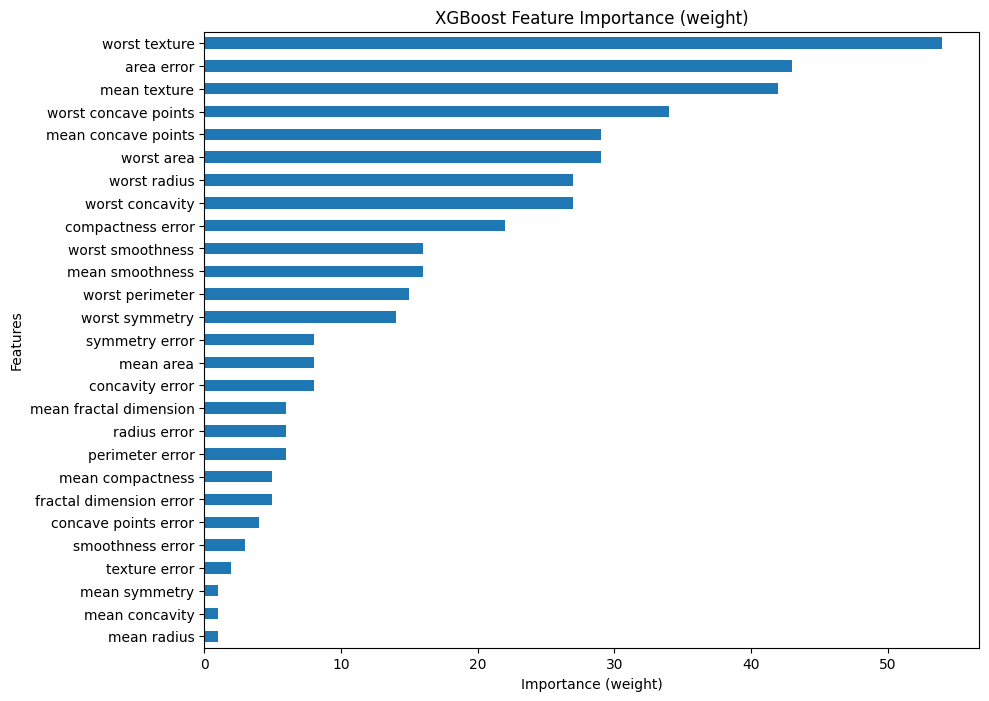

In [ ]:
import matplotlib.pyplot as plt
# The 'model' object is the trained XGBoost model from the previous cell

# Get feature importances
importance = model.get_score(importance_type='weight')

# Convert to pandas Series for easier plotting
importance_series = pd.Series(importance)

# Sort the features by importance
importance_series.sort_values(ascending=True, inplace=True)

# Plot feature importance
plt.figure(figsize=(10, 8))
importance_series.plot(kind='barh')
plt.title('XGBoost Feature Importance (weight)')
plt.xlabel('Importance (weight)')
plt.ylabel('Features')
plt.show()

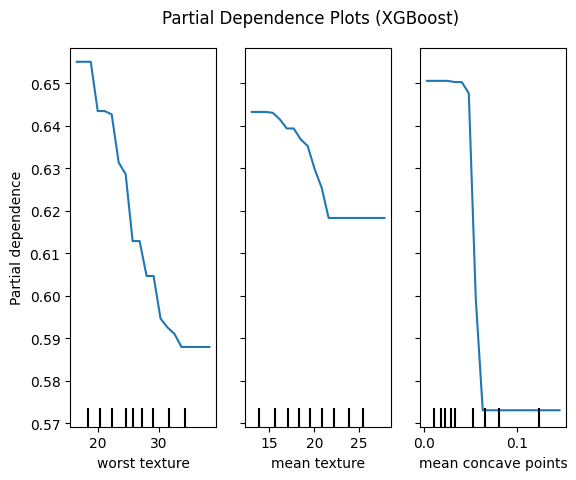

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Assuming 'xgb_model' is your trained XGBoost model (using the scikit-learn API)
# and X_train_xgb, X_test_xgb are your data

# Select features to plot partial dependence for
features_to_plot = ['worst texture', 'mean texture', 'mean concave points'] # Example features

# Create partial dependence plots
PartialDependenceDisplay.from_estimator(xgb_model, X_test_xgb, features_to_plot,
                                  feature_names=X_test_xgb.columns.tolist(),
                                  grid_resolution=20)

plt.suptitle('Partial Dependence Plots (XGBoost)')
plt.subplots_adjust(top=0.9) # Adjust subplot to make space for title
plt.show()

## Linear Algebra Review